## Libraries

In [61]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    `cudnn.benchmark = False` can cost a bit of throughput - autotuning
    normally picks the fastest kernel for the input shape - an acceptable
    trade for bit-reproducible runs. Determinism is only guaranteed on the
    SAME machine / CUDA / torch version - it is not portable across hardware
    or library versions.

    NOTE: this notebook's training loop batches by indexing GPU-resident
    tensors directly (torch.randperm for shuffling) rather than a
    DataLoader/TensorDataset - there's no multiprocess data-loading worker
    to seed separately, so set_seed()'s torch.manual_seed/cuda.manual_seed_all
    already covers the shuffling order.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

Using device: cuda


In [62]:
# ---------------------------------------------------------------------------
# Paths - 2 leptons + 2 taus, Run 2 and Run 3 (same source files as
# Final_Notebooks/2L2Tau_Master_Pipeline.ipynb, so the AUC is directly
# comparable to the XGBoost baseline).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/2l2tau/run3")

# Active run used by downstream cells by default.
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "2 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy (identical to the XGBoost master
# pipeline, so the two models see the same information).
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass2l2tau","tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto",
    "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong",
    "mZ_cut", "mZreq"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

In [63]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    
    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 and Run 3 Data (Shared Setup)

In [64]:
# Run 2 load

candidate_features_run2 = discover_common_features(BASE_DIR_RUN2)
data_run2 = load_run_data(BASE_DIR_RUN2, candidate_features_run2)
data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)

# Run 3 load (prepared now; used later in a separate downstream section)

candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

# Default active dataset for downstream cells in this first pass: Run 2.

candidate_features, data, features = candidate_features_run2, data_run2, features_run2
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"

print(f"Prepared datasets: Run2={len(data_run2)} events, Run3={len(data_run3)} events")
print(f"Downstream now uses: {ACTIVE_RUN}")

88 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    31959 events after preselection
signal_VBF  :     5598 events after preselection
Diboson     :    36877 events after preselection
Zjets       :     7746 events after preselection
Wjets       :       67 events after preselection
ttbar       :      331 events after preselection
tops        :     3832 events after preselection
SingleH     :     2946 events after preselection
Vgamma      :     2019 events after preselection
VVV         :     3593 events after preselection
Dropped 7 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id', 'xgb_score']

81 final features
Total: 94968 events | signal = 37557 | background = 57411
Yield (w_phys): signal = 0.42 | background = 1034.16
88 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    96909 events after preselection
signal_VBF  :     3439 events after preselection
Diboson     :    8

## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [65]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the Task-2 missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504833                      2.0
l2_charge         0.495167                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing

Deterministic two-stage stratified **80/10/10** train/val/test split
(`make_3way_split`) - IDENTICAL logic/seed to
`2L2Tau_Master_Pipeline.ipynb`'s `make_3way_split`, so both notebooks land on
byte-identical partitions. **TEST is held out**: it does not participate in
the median imputation, the `StandardScaler` fit, the `flag_cols` definition,
early stopping, or the significance-scan score-cut selection below - it is
only read once, in the "Held-Out Test Evaluation" cell at the end of this
section, and its partition is persisted to disk and cross-checked against
`2L2Tau_Master_Pipeline.ipynb`'s copy (same `BASE_DIR`).

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
values are median-imputed (fit on the train split only) before standard
scaling. Missingness itself is informative to XGBoost (it learns a default
split direction for NaN) - imputation would erase that signal for the MLP,
so explicit `__isnan` flag columns (schema derived from train only) are
concatenated onto the scaled features to level the field. Training weights
are class-balanced and mean-normalized so the much larger background yield
doesn't dominate the loss; validation/test weights stay as plain `|w_phys|`
so AUC reflects the true class balance.


In [66]:
def make_fit_weights(labels, abs_weights):

    """
    Balance signal/background total weight and normalize the mean weight
    to 1. `abs_weights` must already be non-negative (Sherpa weights can be
    negative).
    """

    labels = np.asarray(labels)

    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split -
    IDENTICAL logic (same seed, same stratify) to
    2L2Tau_Master_Pipeline.ipynb's make_3way_split, so both notebooks land
    on byte-identical partitions whenever they build `data` the same way
    (same FILES order -> concat -> clean_data).

    TEST must not participate in anything until it is scored exactly once at
    the very end: not the median imputation, not the StandardScaler fit,
    not `flag_cols`, not early stopping, not the significance-scan score-cut
    selection.

    Stage 1 peels off `test_size` (10%) as TEST. Stage 2 splits the
    remaining (1 - test_size) into train/val; to get `val_size` (10%) OF THE
    FULL SAMPLE, stage 2's test_size must be val_size / (1 - test_size) =
    0.10 / 0.90 = 1/9, NOT val_size itself - using 0.10 there would silently
    give 9% val / 81% train instead of the intended 80/10/10.
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")
        if extra_stratify_col is not None:
            print(f"       {extra_stratify_col} mix: {df[extra_stratify_col].value_counts().sort_index().to_dict()}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path` (e.g. written by 2L2Tau_Master_Pipeline.ipynb reading the exact
    same BASE_DIR), verify this notebook's freshly-computed `test_df` is
    byte-identical to it on their shared columns. "Same helper, same seed"
    only guarantees identical partitions if the input `data` was built
    identically (same FILES order -> concat -> clean_data) - this is the
    actual proof, not an assumption.
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    # check_dtype=False: ROOT/uproot round-tripping (and this branch being
    # written by a sibling notebook with its own w_phys formula) can shift
    # float32/float64 precision without the underlying partition actually
    # differing - a tight numeric tolerance is the real cross-check, not
    # bit-for-bit dtype identity.
    
    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


def persist_test_partition(test_df, split_dir):

    """
    Persist just TEST to disk under `split_dir` (train/val are already
    written by 2L2Tau_Master_Pipeline.ipynb into the same directory, since
    both notebooks share BASE_DIR_RUN2/BASE_DIR_RUN3) - cross-checks against
    any prior test.root there first.
    """

    split_dir = Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    test_path = split_dir / "test.root"
    assert_same_test_partition(test_df, test_path)
    with uproot.recreate(test_path) as f:
        f["tree"] = test_df.reset_index(drop=True)
    print(f"Wrote {len(test_df)} test events -> {test_path}  (held out until final evaluation)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
persist_test_partition(test_df, SPLIT_DIR_RUN2)

X_train_raw, y_train, w_train = train_df[features], train_df["label"].to_numpy(), train_df["w_phys"].to_numpy()
X_val_raw,   y_val,   w_val   = val_df[features],   val_df["label"].to_numpy(),   val_df["w_phys"].to_numpy()
X_test_raw,  y_test,  w_test  = test_df[features],  test_df["label"].to_numpy(),  test_df["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train = X_train_raw.isna()
flag_cols = nan_train.columns[nan_train.any()].tolist()


def make_flags(X_raw):
    """0/1 missingness flags for `flag_cols`, kept unscaled - scaling a 0/1
    flag would just relabel it, not add information."""
    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_val_imp = X_val_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), make_flags(X_train_raw).to_numpy()])
X_val_scaled = np.hstack([scaler.transform(X_val_imp), make_flags(X_val_raw).to_numpy()])
X_test_scaled = np.hstack([scaler.transform(X_test_imp), make_flags(X_test_raw).to_numpy()])

assert np.isfinite(X_train_scaled).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(X_val_scaled).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(X_test_scaled).all(), "NaN/inf reached the model input (test)"

print(f"\n{len(flag_cols)} features had missing values in train -> added {len(flag_cols)} __isnan flag "
      f"columns (final input width = {X_train_scaled.shape[1]} = {len(features)} features + {len(flag_cols)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.

w_train_fit = make_fit_weights(y_train, np.abs(w_train))
w_train_abs = np.abs(w_train)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit = np.abs(w_val)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end, so there is no "fit" version needed.
w_test_fit = np.abs(w_test)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train[y_train==0]).sum() / np.abs(w_train[y_train==1]).sum():.1f}")


Train:    75974 events | signal =   30045 (yield=      0.33) | background =   45929 (yield=    796.57) | signal weight scale factor = 2391.6
Val  :     9497 events | signal =    3756 (yield=      0.04) | background =    5741 (yield=    139.99) | signal weight scale factor = 3326.1
Test :     9497 events | signal =    3756 (yield=      0.04) | background =    5741 (yield=     97.60) | signal weight scale factor = 2352.7
  cross-check OK: PPSSP_2026/2l2tau/run2/splits/test.root test partition matches on 84 shared columns (9497 rows)
Wrote 9497 test events -> PPSSP_2026/2l2tau/run2/splits/test.root  (held out until final evaluation)



28 features had missing values in train -> added 28 __isnan flag columns (final input width = 109 = 81 features + 28 flags)
Signal weight scale factor (train): 2912.1


## PyTorch Dataset & Model

In [67]:
# Model input is small (~150 MB for 552k x 68 floats), so it comfortably fits
# in GPU memory - keep it resident there for the whole run instead of using a
# DataLoader, which would otherwise copy every mini-batch host->device one at
# a time. Batches are then just GPU-side tensor indexing (see run_epoch).

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 256, 128, 128, 64, 32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
w_train_t = torch.tensor(w_train_fit, dtype=torch.float32, device=DEVICE)
w_train_abs_t = torch.tensor(w_train_abs, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
w_val_t = torch.tensor(w_val_fit, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section - kept GPU-resident here purely for consistency with
# train/val, never used by run_epoch/train_model.
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)
w_test_t = torch.tensor(w_test_fit, dtype=torch.float32, device=DEVICE)


class SimpleMLP(nn.Module):

    """
    A deep feed-forward binary classifier: four hidden layers with ReLU
    activations and dropout, single output logit (paired with
    BCEWithLogitsLoss for numerical stability).
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-pruning retrain) can
    build a fresh model per trial without repeating the
    SimpleMLP(...).to(DEVICE) boilerplate. `n_features` defaults to the full
    feature set's width (physics features + missingness flags), but can be
    overridden when training on a feature subset (e.g. after correlation
    pruning).
    """

    if n_features is None:
        n_features = X_train_scaled.shape[1]
    return SimpleMLP(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=109, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [68]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Batching
    and bookkeeping stay on the GPU the whole time - loss/predictions are
    only pulled to the CPU once, at the very end of the epoch - instead of
    calling `.item()`/`.cpu()` inside the loop, which would force a
    CPU<->GPU sync on every single mini-batch and stall the GPU regardless
    of how fast it is.
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None,
                 w_train_eval_data=None):

    """
    Build a fresh SimpleMLP(hidden_sizes, dropout) and train it with early
    stopping on weighted validation AUC. This is the unit a hyperparameter
    search (or a feature-pruning retrain) calls once per trial, varying
    `hidden_sizes` and/or the train/val tensors (e.g. a feature subset after
    correlation pruning - pass X_train_data/X_val_data with fewer columns).
    Data args default to the full-feature GPU-resident tensors
    (X_train_t/y_train_t/w_train_t/X_val_t/y_val_t/w_val_t).

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, default
    `w_train_abs_t`) - the dropout-ON / balanced-fit-weight numbers logged as
    "train_auc"/"train_loss" are tuned for gradient stability, not for
    reading off an honest train/val gap, so they're not directly comparable
    to the val curve (dropout off, |w_phys|). The eval-mode numbers
    ("train_auc_eval"/"train_loss_eval") are.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded; `best_train_auc`/
    `best_train_auc_eval` are read off that SAME epoch (not just the last
    one), so all three numbers are directly comparable.
    """

    X_train_data = X_train_t if X_train_data is None else X_train_data
    y_train_data = y_train_t if y_train_data is None else y_train_data
    w_train_data = w_train_t if w_train_data is None else w_train_data
    X_val_data = X_val_t if X_val_data is None else X_val_data
    y_val_data = y_val_t if y_val_data is None else y_val_data
    w_val_data = w_val_t if w_val_data is None else w_val_data
    w_train_eval_data = w_train_abs_t if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

Epoch   1 | train_loss=0.6887 val_loss=0.6342 | train_auc=0.5968 train_auc_eval=0.8564 val_auc=0.8748
Epoch   2 | train_loss=0.6033 val_loss=0.3261 | train_auc=0.8190 train_auc_eval=0.9020 val_auc=0.9075
Epoch   3 | train_loss=0.4378 val_loss=0.2269 | train_auc=0.8829 train_auc_eval=0.9248 val_auc=0.9494
Epoch   4 | train_loss=0.3725 val_loss=0.3062 | train_auc=0.9143 train_auc_eval=0.9357 val_auc=0.9525
Epoch   5 | train_loss=0.3656 val_loss=0.3046 | train_auc=0.9183 train_auc_eval=0.9428 val_auc=0.9518
Epoch   6 | train_loss=0.3286 val_loss=0.2653 | train_auc=0.9345 train_auc_eval=0.9467 val_auc=0.9566
Epoch   7 | train_loss=0.3253 val_loss=0.2357 | train_auc=0.9357 train_auc_eval=0.9501 val_auc=0.9574
Epoch   8 | train_loss=0.3123 val_loss=0.2596 | train_auc=0.9414 train_auc_eval=0.9531 val_auc=0.9574
Epoch   9 | train_loss=0.3069 val_loss=0.2728 | train_auc=0.9428 train_auc_eval=0.9559 val_auc=0.9572
Epoch  10 | train_loss=0.2950 val_loss=0.2666 | train_auc=0.9473 train_auc_eval=0.

Epoch  11 | train_loss=0.2905 val_loss=0.3125 | train_auc=0.9487 train_auc_eval=0.9595 val_auc=0.9558
Epoch  12 | train_loss=0.2862 val_loss=0.2485 | train_auc=0.9504 train_auc_eval=0.9608 val_auc=0.9589
Epoch  13 | train_loss=0.2783 val_loss=0.2482 | train_auc=0.9530 train_auc_eval=0.9621 val_auc=0.9556
Epoch  14 | train_loss=0.2749 val_loss=0.2513 | train_auc=0.9541 train_auc_eval=0.9633 val_auc=0.9575
Epoch  15 | train_loss=0.2699 val_loss=0.2688 | train_auc=0.9557 train_auc_eval=0.9646 val_auc=0.9573
Epoch  16 | train_loss=0.2687 val_loss=0.3225 | train_auc=0.9564 train_auc_eval=0.9658 val_auc=0.9550
Epoch  17 | train_loss=0.2606 val_loss=0.3409 | train_auc=0.9589 train_auc_eval=0.9670 val_auc=0.9530
Epoch  18 | train_loss=0.2606 val_loss=0.3096 | train_auc=0.9589 train_auc_eval=0.9676 val_auc=0.9546
Epoch  19 | train_loss=0.2549 val_loss=0.3934 | train_auc=0.9607 train_auc_eval=0.9685 val_auc=0.9532
Epoch  20 | train_loss=0.2550 val_loss=0.3269 | train_auc=0.9605 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes)

A minimal grid search: `train_model` is called once per candidate
`hidden_sizes` architecture (deeper/shallower, wider/narrower), and the
config with the best weighted validation AUC is kept as the final `model`.
Swap `HIDDEN_SIZE_OPTIONS` for a random/Optuna search later without touching
`train_model` itself - it already takes `hidden_sizes` as a plain argument.

In [69]:
HIDDEN_SIZE_OPTIONS = [
    (64,),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64, 32),
]

search_results = []
best_search_auc, best_hidden_sizes = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(hidden_sizes=hidden_sizes, verbose=False)
    search_results.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc:
        best_search_auc, best_hidden_sizes = trial_val_auc, hidden_sizes
        model, history, best_val_auc, best_train_auc, best_train_auc_eval = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes} | val_auc={best_search_auc:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9529 val_auc=0.9603
hidden_sizes=(128, 64)        -> train_auc=0.9534 val_auc=0.9601


KeyboardInterrupt: 

## Evaluation

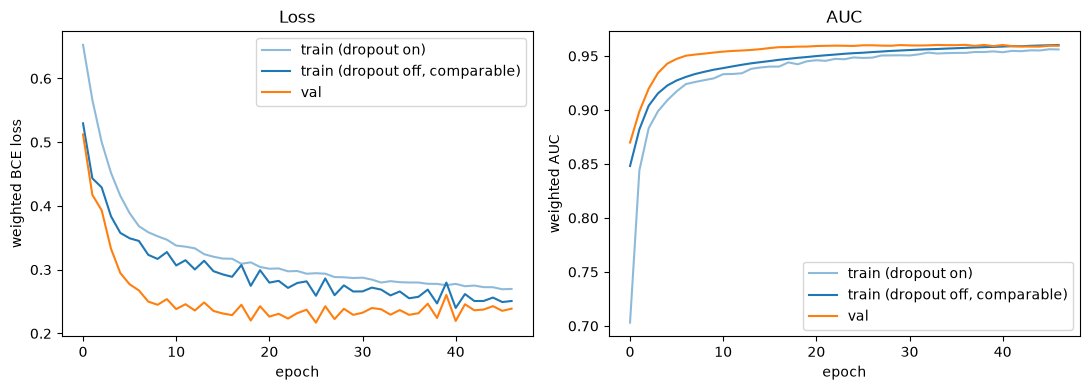

Final weighted AUC: train=0.9575 val=0.9603


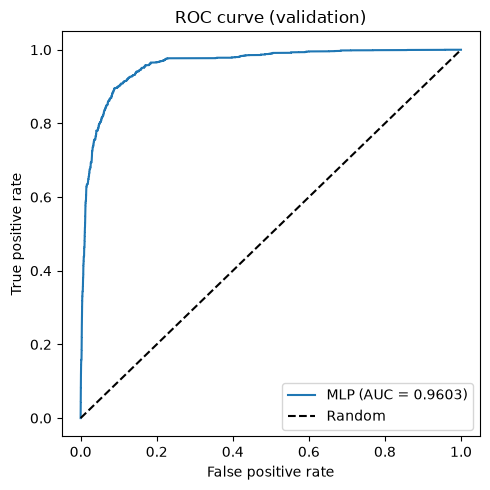

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

# NOTE: the faint "train (dropout on)" curve is measured mid-training with
# dropout active and class-balanced fit-weights - it's what the optimizer
# actually sees, not a fair comparison to val. The solid "train (dropout
# off, comparable)" curve (same eval mode + |w_phys| weights as val) is the
# one to read an honest train/val gap off of.

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    val_probs = torch.sigmoid(model(torch.tensor(X_val_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()

auc_train = roc_auc_score(y_train, train_probs, sample_weight=np.abs(w_train))
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_fit)

print(f"Final weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_fit)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

XGBoost has a built-in gain-based importance, but a neural net doesn't - the
model-agnostic equivalent is **permutation importance**: shuffle one
feature's column across events (destroying its relationship with the
label) and measure how much the weighted validation AUC drops. Repeated a
few times per feature and averaged for stability. Computed on the
validation set so it isn't inflated by the model simply memorizing train.

In [71]:
def permutation_importance(model, X, y, w, features, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors (e.g. X_val_t/y_val_t/w_val_t) with columns in the
    same order as `features`. Returns a pandas Series (feature -> mean AUC
    drop), sorted descending - a bigger drop means the model relies on that
    feature more.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(features):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=features, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance (same
    convention as the XGBoost master pipeline's plot_importance_bar). If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted AUC: 0.9603


Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2ImportanceFull_DNN.png


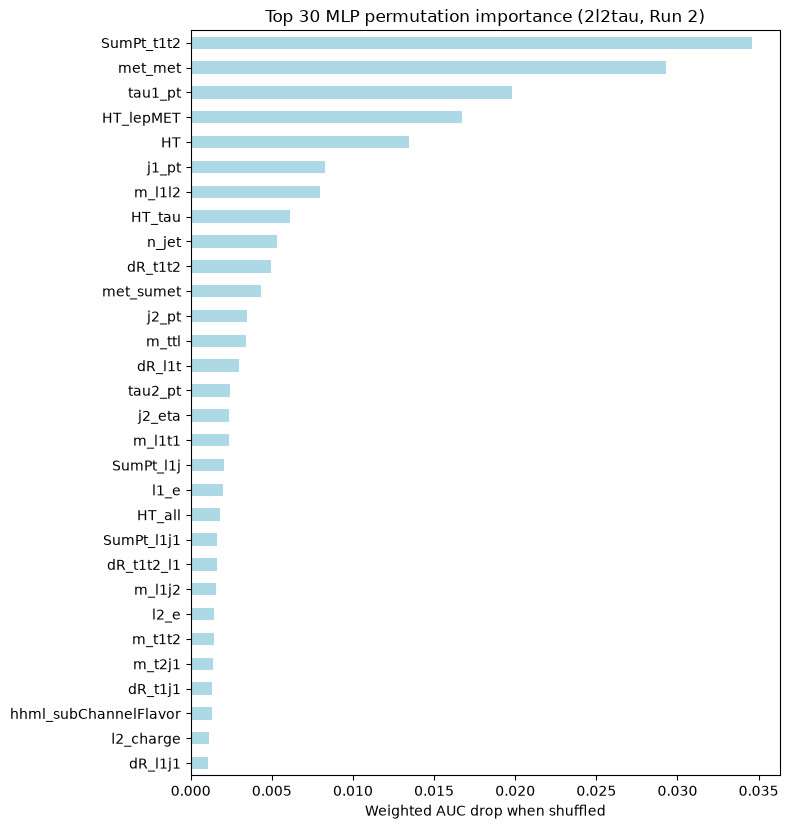

SumPt_t1t2    0.034589
met_met       0.029319
tau1_pt       0.019780
HT_lepMET     0.016743
HT            0.013479
j1_pt         0.008286
m_l1l2        0.007938
HT_tau        0.006118
n_jet         0.005341
dR_t1t2       0.004978
met_sumet     0.004303
j2_pt         0.003461
m_ttl         0.003379
dR_l1t        0.002952
tau2_pt       0.002410
Name: auc_drop, dtype: float64

In [72]:
importance = permutation_importance(model, X_val_t, y_val_t, w_val_t, features, n_repeats=5)
PLOTS_DIR_R2 = BASE_DIR_RUN2 / "plots"
PLOTS_DIR_R2.mkdir(parents=True, exist_ok=True)
plot_importance_bar(importance, top_n=30, title="Top 30 MLP permutation importance (2l2tau, Run 2)",
                     save_path=PLOTS_DIR_R2 / "Run2ImportanceFull_DNN.png")
importance.head(15)

## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's correlation-pruning stage: rank
features by importance (permutation importance here, gain there), look at
Pearson correlation among the top candidates separately for signal and
background, then walk the ranked list keeping a feature only if it isn't
too correlated (`|corr| > 0.75`) with a more important feature already kept.
The MLP is then retrained from scratch on the decorrelated feature set, and
again restricted to just the top 15 features, to see how much (if any)
performance is lost by cutting redundant/less useful inputs.

In [73]:
TOP_N_IMPORTANCE = 30   # candidate pool size, before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors(feature_subset, all_features=features):
    
    """
    Slice the already-scaled train/val/test numpy arrays down to
    `feature_subset` (columns picked by name, matching `all_features`'
    order) and move the result to GPU-resident tensors - the same shape
    train_model expects. The test slice is never used for training/model
    selection - it exists only so the eventually-chosen final model can be
    scored on test once, at the end.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationTop30_DNN.png


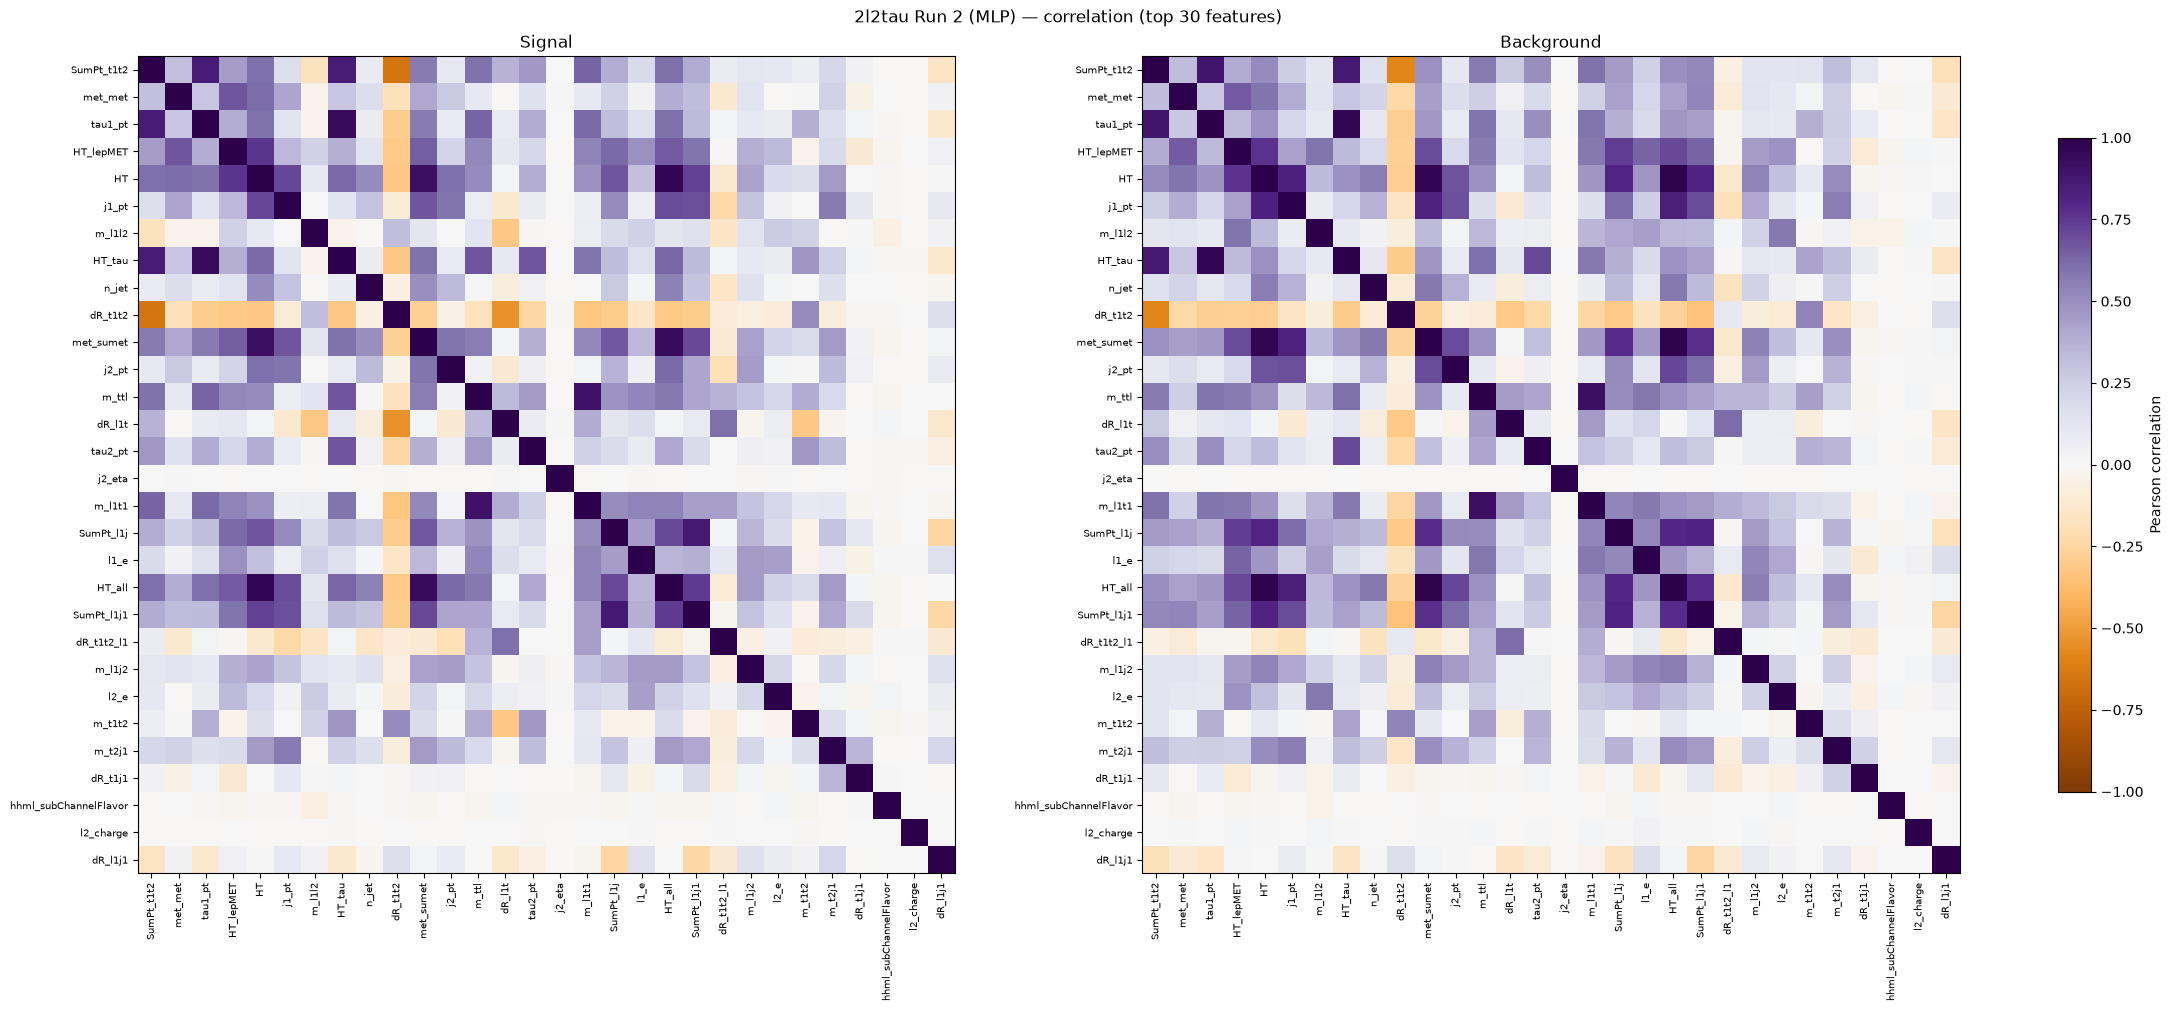

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.964857
tau1_pt     HT_tau        0.945010
met_sumet   HT_all        0.941744
HT          met_sumet     0.921631
m_ttl       m_l1t1        0.905892
SumPt_l1j   SumPt_l1j1    0.869891
SumPt_t1t2  tau1_pt       0.857742
            HT_tau        0.856143
HT_lepMET   HT            0.759815
HT_all      SumPt_l1j1    0.745238
HT          SumPt_l1j1    0.730138
            j1_pt         0.715593
met_sumet   SumPt_l1j1    0.707778
SumPt_l1j   HT_all        0.707289

Pairs with |corr| > 0.50 (background):
HT          HT_all        0.983498
met_sumet   HT_all        0.979469
HT          met_sumet     0.967208
tau1_pt     HT_tau        0.965406
m_ttl       m_l1t1        0.919120
SumPt_t1t2  tau1_pt       0.883633
            HT_tau        0.870515
j1_pt       HT_all        0.839818
HT          j1_pt         0.834814
j1_pt       met_sumet     0.824530
SumPt_l1j   SumPt_l1j1    0.815491
HT          SumPt_l1j1    0.813016
            Sum

In [74]:
# ---- Correlation of the top-30 permutation-important features -------------

top_feats = importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(data, top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"2l2tau Run 2 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())

In [75]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. SumPt_t1t2
   2. met_met
   3. HT_lepMET
   4. j1_pt
   5. m_l1l2
   6. n_jet
   7. dR_t1t2
   8. j2_pt
   9. m_ttl
  10. dR_l1t
  11. tau2_pt
  12. j2_eta
  13. SumPt_l1j
  14. l1_e
  15. dR_t1t2_l1
  16. m_l1j2
  17. l2_e
  18. m_t1t2
  19. m_t2j1
  20. dR_t1j1

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with SumPt_t1t2      (|corr| = 0.884)
  HT              -> redundant with HT_lepMET       (|corr| = 0.766)
  HT_tau          -> redundant with SumPt_t1t2      (|corr| = 0.871)
  met_sumet       -> redundant with j1_pt           (|corr| = 0.825)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.919)
  HT_all          -> redundant with j1_pt           (|corr| = 0.840)
  SumPt_l1j1      -> redundant with SumPt_l1j       (|corr| = 0.870)


Full model      (81 features): train_auc_eval = 0.9575 | val_auc = 0.9603
Pruned model     (20 features): train_auc_eval = 0.9513 | val_auc = 0.9609
Baseline weighted AUC: 0.9609
Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2ImportancePruned_DNN.png


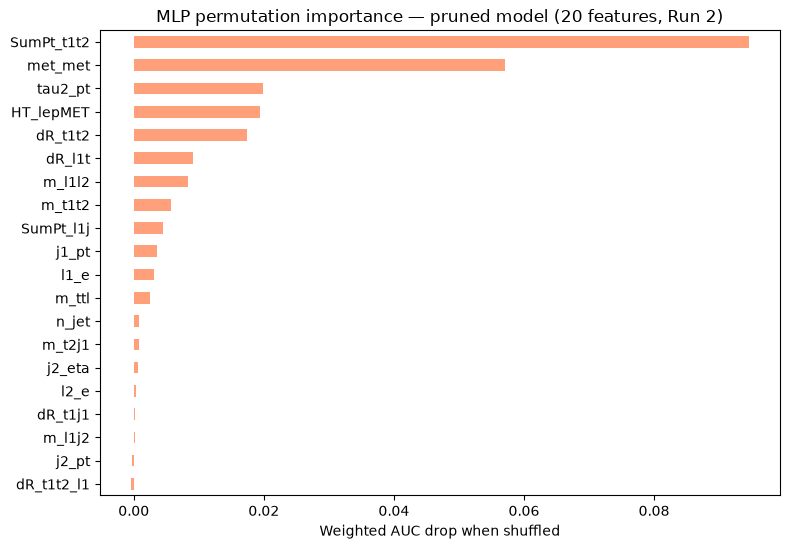

Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2CorrelationPruned_DNN.png


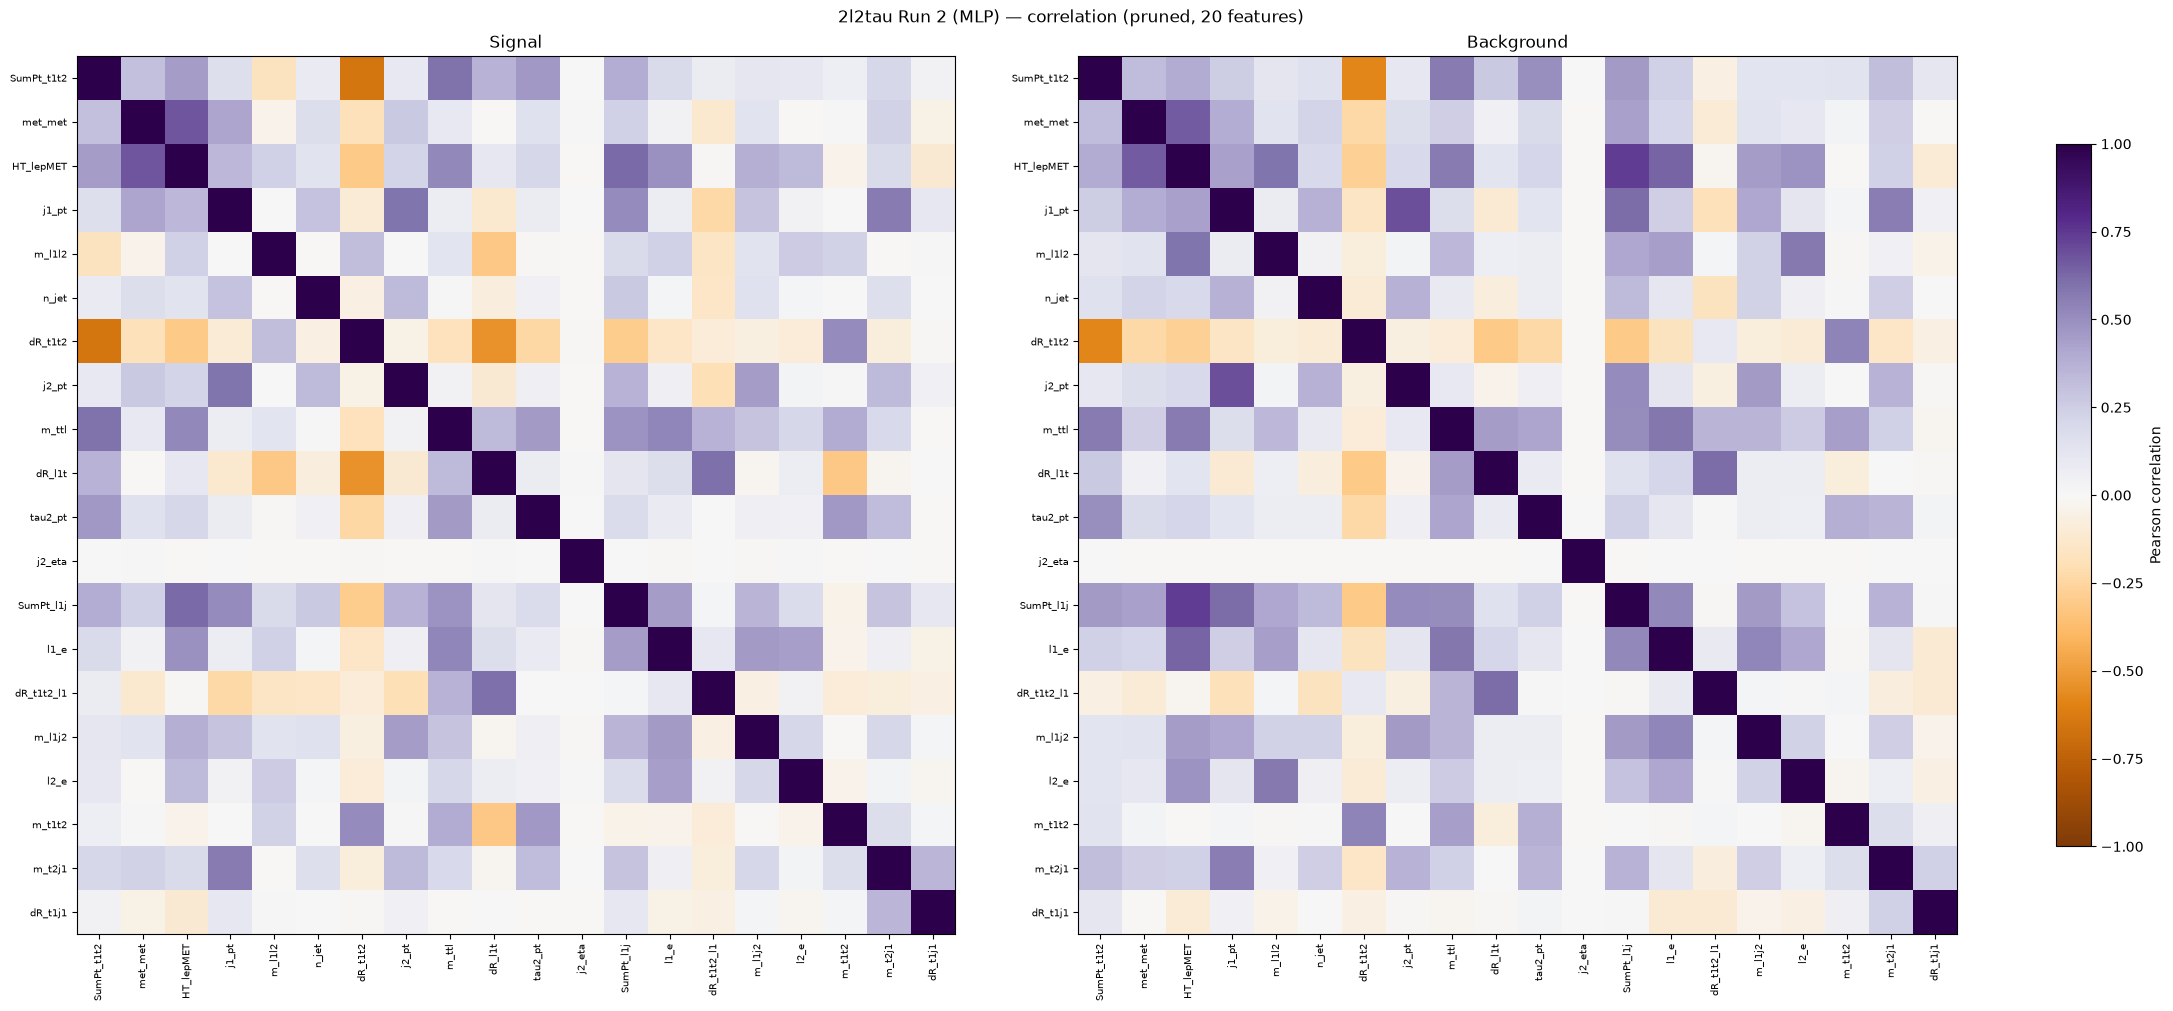

In [76]:
# ---- Retrain on the pruned feature set --------------------------------
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors(PRUNED_FEATURES)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    hidden_sizes=best_hidden_sizes, verbose=False,
    X_train_data=X_train_pruned_t, X_val_data=X_val_pruned_t,
)

print(f"Full model      ({len(features):2d} features): train_auc_eval = {best_train_auc_eval:.4f} | val_auc = {best_val_auc:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES):2d} features): train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, y_val_t, w_val_t, PRUNED_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_FEATURES),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES)} features, Run 2)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R2 / "Run2ImportancePruned_DNN.png",
)

pruned_corrs = grouped_correlations(data, PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"2l2tau Run 2 (MLP) — correlation (pruned, {len(PRUNED_FEATURES)} features)",
    save_path=PLOTS_DIR_R2 / "Run2CorrelationPruned_DNN.png",
)

## Top-15 Features Only

Same correlation-pruning walk over the same top-30 candidate pool, but
stopped once 15 decorrelated features are kept, to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set.

Kept 15 decorrelated features (most -> least important):
   1. SumPt_t1t2
   2. met_met
   3. HT_lepMET
   4. j1_pt
   5. m_l1l2
   6. n_jet
   7. dR_t1t2
   8. j2_pt
   9. m_ttl
  10. dR_l1t
  11. tau2_pt
  12. j2_eta
  13. SumPt_l1j
  14. l1_e
  15. dR_t1t2_l1

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with SumPt_t1t2      (|corr| = 0.884)
  HT              -> redundant with HT_lepMET       (|corr| = 0.766)
  HT_tau          -> redundant with SumPt_t1t2      (|corr| = 0.871)
  met_sumet       -> redundant with j1_pt           (|corr| = 0.825)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.919)
  HT_all          -> redundant with j1_pt           (|corr| = 0.840)
  SumPt_l1j1      -> redundant with SumPt_l1j       (|corr| = 0.870)


Baseline weighted AUC: 0.9599
Saved plot -> PPSSP_2026/2l2tau/run2/plots/Run2ImportanceTop15_DNN.png


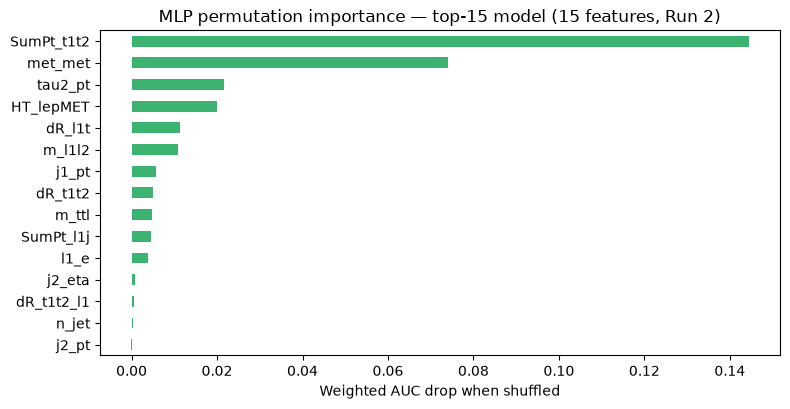


Weighted train(eval-mode)/validation AUC comparison:


,model,train_auc_eval,val_auc
1,Pruned (20 features),0.951265,0.960870
0,Full (81 features),0.957543,0.960293
2,Top-15 (15 features),0.948289,0.959920


In [77]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors(TOP15_FEATURES)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    hidden_sizes=best_hidden_sizes, verbose=False,
    X_train_data=X_train_top15_t, X_val_data=X_val_top15_t,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, y_val_t, w_val_t, TOP15_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_FEATURES),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES)} features, Run 2)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R2 / "Run2ImportanceTop15_DNN.png",
)

comparison = pd.DataFrame([
    {"model": f"Full ({len(features)} features)", "train_auc_eval": best_train_auc_eval, "val_auc": best_val_auc},
    {"model": f"Pruned ({len(PRUNED_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned, "val_auc": val_auc_pruned},
    {"model": f"Top-15 ({len(TOP15_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15, "val_auc": val_auc_top15},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison:")
comparison

## Physics Figure of Merit & Final Summary

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This section reports a max-Asimov-significance
scan for the **last pruned model (top-15 features)** - the most
decorrelated/interpretable feature set from the pruning walk above - plus a
low-FPR ROC view and signal efficiency at fixed background-rejection
working points, all still on **VAL** (used for model/cut selection).

A genuinely blind estimate follows in the "Held-Out Test Evaluation" cell
below: the VAL-selected score cut is applied FROZEN to the never-before-seen
**TEST** partition (10% of the sample, held out by `make_3way_split` since
before preprocessing), reporting test AUC and test Z at that cut exactly
once - this is what actually answers "how good is this model", since VAL
was used to pick both the model and the cut.

In [78]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|) - S and B are physical yields, not event counts.
    `min_bkg` guards the sparse high-score tail where Z is unstable/
    unphysical when B is tiny or negative. Caveat: signed sums CAN drive S
    or B negative in sparse bins (the S>0/min_bkg guards handle it); the
    absolute Z value depends on sample normalization/luminosity, so treat it
    as a RELATIVE metric for ranking models on the identical rows, not an
    absolute discovery number.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))  # Asimov; -> S/sqrt(B) for S<<B
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the pruning walk above. The score CUT is
# selected here by scanning VAL only - it is applied FROZEN to test in the
# "Held-Out Test Evaluation" cell below, never re-scanned there.
models_registry = {
    f"Full ({len(features)} features)": (model, X_val_t, X_test_t),
    f"Pruned ({len(PRUNED_FEATURES)} features)": (model_pruned, X_val_pruned_t, X_test_pruned_t),
    f"Top-15 ({len(TOP15_FEATURES)} features)": (model_top15, X_val_top15_t, X_test_top15_t),
}
best_name = f"Top-15 ({len(TOP15_FEATURES)} features)"

final_model, X_val_final_t, X_test_final_t = models_registry[best_name]

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

z_val, thr_val = significance_scan(y_val, val_scores, w_val)  # signed w_phys - expected yields
final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name}")
print(f"Weighted val AUC = {final_val_auc:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9599
Max Asimov Z (val) = 0.020 at score cut = 0.8553


### Held-Out Test Evaluation (Run 2)

`X_test_final_t`/`y_test`/`w_test` have not participated in anything above -
not the imputation/scaler fit, not correlation pruning, not hyperparameter
search, not early stopping, not the score-cut selection just above. This is
the one place they are read: the final model is scored once, and the
VAL-selected score cut is applied frozen (not re-scanned).


In [79]:
# ---- HELD-OUT TEST EVALUATION (Run 2) — scored EXACTLY ONCE ----------------
# X_test_final_t/y_test/w_test have not been touched anywhere above (not the
# imputation/scaler fit, not correlation pruning, not hyperparameter search,
# not early stopping, not the significance-scan score-cut selection just
# above) - this is the only cell in the Run 2 section that reads them. The
# score cut `thr_val` was chosen by scanning VAL only; it is applied here
# FROZEN, NOT re-scanned on test.

final_model.eval()
with torch.no_grad():
    test_scores = torch.sigmoid(final_model(X_test_final_t)).cpu().numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_fit)

S_test = w_test[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"Final model: {best_name}")
print(f"Weighted AUC: val = {final_val_auc:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9599  |  test (held-out, scored once) = 0.9519
At the VAL-selected score cut = 0.8553 (frozen, NOT re-scanned on test):
  test S = 0.02 | test B = 2.10 | test Z = 0.017  (val Z was 0.020)


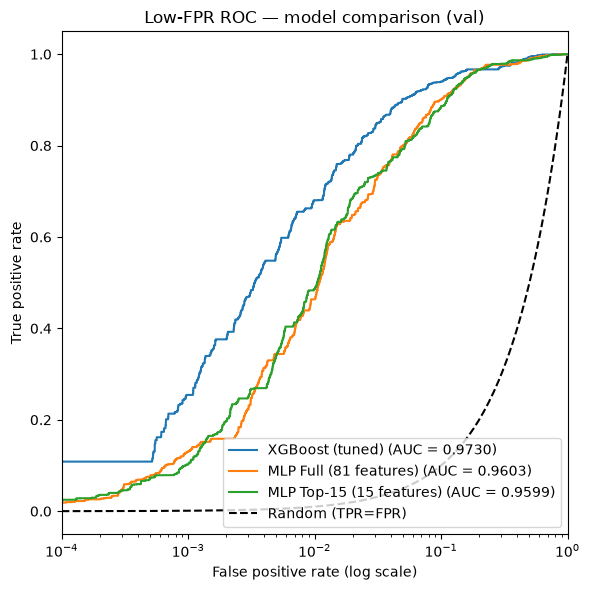

--- FPR = 1e-03 (~6 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.2545  (254x random lift)
  MLP Full (81 features)           TPR = 0.1305  (131x random lift)
  MLP Top-15 (15 features)         TPR = 0.1023  (102x random lift)
--- FPR = 1e-02 (~57 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.6804  (68x random lift)
  MLP Full (81 features)           TPR = 0.4636  (46x random lift)
  MLP Top-15 (15 features)         TPR = 0.4855  (49x random lift)


In [80]:
# ---- Load the tuned XGBoost model (same 2l2tau Run 2 track) for an
# apples-to-apples overlay. Both notebooks build `data` identically and
# split 80/20 with the same seed/stratify-on-label, so val_df here is the
# same event set as the XGBoost pipeline's holdout - no need to reload data.

import xgboost as xgb

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(BASE_DIR / "final_model_run2.json")
with open(BASE_DIR / "optuna_features_run2.json") as f:
    xgb_features = json.load(f)

xgb_val_scores = xgb_model.predict_proba(val_df[xgb_features])[:, 1]


def roc_with_auc(y_true, scores, w):
    fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=w)
    auc = roc_auc_score(y_true, scores, sample_weight=w)
    return fpr, tpr, auc


# Model-vs-model overlay on the SAME val rows/|w_phys| weights - this is the
# plot that actually answers "which model holds more signal at fixed
# background rejection", not a single curve vs. a (wrong) diagonal.

# ROC curve for the FINAL model (top-15 pruned, `val_scores` from the
# significance-scan cell above), not the full model - matches the `best_name` label.
fpr_val, tpr_val, _ = roc_curve(y_val, val_scores, sample_weight=w_val_fit)

curves = {
    "XGBoost (tuned)": roc_with_auc(y_val, xgb_val_scores, w_val_fit),
    f"MLP Full ({len(features)} features)": roc_with_auc(y_val, val_probs, w_val_fit),
    f"MLP {best_name}": (fpr_val, tpr_val, final_val_auc),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")


x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val)")
plt.legend()
plt.tight_layout()
plt.show()

# Caveat: below ~1e-3 FPR the surviving background is down to O(100) MC
# events, so the leftmost decade - especially any uptick right at the 1e-4
# edge - is statistical wobble, not a real effect. 

n_bkg_val = int((y_val == 0).sum())

for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

In [81]:
# ---- Sanity checks --------------------------------------------------------

assert np.isfinite(X_train_scaled).all() and np.isfinite(X_val_scaled).all() and np.isfinite(X_test_scaled).all(), \
    "NaN/inf reached the model input"

# Determinism check (Task 1's acceptance criterion): re-seeding immediately
# before each of two short training runs should give an EXACT match, proving
# set_seed()/use_deterministic_algorithms(True) actually pin every source of
# randomness (weight init, dropout masks, batch shuffling). Uses a cheap
# config (small model, 5 epochs) purely to keep this check fast - it is not
# meant to reflect final model quality.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test, z_test at the frozen,
# VAL-selected score cut).

summary = pd.DataFrame([{
    "model": best_name,
    "train_auc_eval": final_train_auc_eval,
    "val_auc": final_val_auc,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (MLP, 2l2tau Run 2):")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.938986

Final summary (MLP, 2l2tau Run 2):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.948289  0.95992            0.019536                          0.951935                      0.017122


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.948289,0.95992,0.019536,0.951935,0.017122


## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. To start a separate Run 3 pass,
run the next cell to switch the active dataset, then continue with your
Run 3 downstream cells.

In [85]:
# Activate Run 3 as the downstream dataset. Everything below uses `_run3`
# suffixed variable names so the Run 2 results above remain untouched.

candidate_features, data, features = candidate_features_run3, data_run3, features_run3

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"Switched downstream dataset to: {ACTIVE_RUN}")
print(f"Events={len(data)} | features={len(features)}")

Switched downstream dataset to: Run 3
Events=229542 | features=81


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [86]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

# Apply the (currently empty) mask before the train/val split, same convention as Run 2.
for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)
if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504539                      2.0
l2_charge         0.495461                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation Split & Preprocessing — Run 3

Same 80/20 stratified split, median imputation (fit on train only),
standard scaling, and `__isnan` missingness flags as the Run 2 section,
applied to `data_run3`. Kept in separate `_run3` variables so the Run 2
train/val tensors above are unaffected.

In [87]:
train_df_run3, val_df_run3, test_df_run3 = make_3way_split(data_run3)

SPLIT_DIR_RUN3 = BASE_DIR_RUN3 / "splits"
persist_test_partition(test_df_run3, SPLIT_DIR_RUN3)

X_train_raw_run3, y_train_run3, w_train_run3 = train_df_run3[features_run3], train_df_run3["label"].to_numpy(), train_df_run3["w_phys"].to_numpy()
X_val_raw_run3,   y_val_run3,   w_val_run3   = val_df_run3[features_run3],   val_df_run3["label"].to_numpy(),   val_df_run3["w_phys"].to_numpy()
X_test_raw_run3,  y_test_run3,  w_test_run3  = test_df_run3[features_run3],  test_df_run3["label"].to_numpy(),  test_df_run3["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train_run3 = X_train_raw_run3.isna()
flag_cols_run3 = nan_train_run3.columns[nan_train_run3.any()].tolist()


def make_flags_run3(X_raw):
    """Run 3 version of make_flags: 0/1 missingness flags for `flag_cols_run3`."""
    f = X_raw[flag_cols_run3].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols_run3]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians_run3 = X_train_raw_run3.median()
X_train_imp_run3 = X_train_raw_run3.fillna(train_medians_run3)
X_val_imp_run3 = X_val_raw_run3.fillna(train_medians_run3)
X_test_imp_run3 = X_test_raw_run3.fillna(train_medians_run3)

scaler_run3 = StandardScaler()
X_train_scaled_run3 = np.hstack([scaler_run3.fit_transform(X_train_imp_run3), make_flags_run3(X_train_raw_run3).to_numpy()])
X_val_scaled_run3 = np.hstack([scaler_run3.transform(X_val_imp_run3), make_flags_run3(X_val_raw_run3).to_numpy()])
X_test_scaled_run3 = np.hstack([scaler_run3.transform(X_test_imp_run3), make_flags_run3(X_test_raw_run3).to_numpy()])

assert np.isfinite(X_train_scaled_run3).all(), "NaN/inf reached the model input (train, Run 3)"
assert np.isfinite(X_val_scaled_run3).all(), "NaN/inf reached the model input (val, Run 3)"
assert np.isfinite(X_test_scaled_run3).all(), "NaN/inf reached the model input (test, Run 3)"

print(f"\n{len(flag_cols_run3)} features had missing values in train -> added {len(flag_cols_run3)} __isnan flag "
      f"columns (final input width = {X_train_scaled_run3.shape[1]} = {len(features_run3)} features + {len(flag_cols_run3)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.
w_train_fit_run3 = make_fit_weights(y_train_run3, np.abs(w_train_run3))
w_train_abs_run3 = np.abs(w_train_run3)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit_run3 = np.abs(w_val_run3)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end.
w_test_fit_run3 = np.abs(w_test_run3)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train_run3[y_train_run3==0]).sum() / np.abs(w_train_run3[y_train_run3==1]).sum():.1f}")


Train:   183632 events | signal =   80278 (yield=      0.39) | background =  103354 (yield=   1697.83) | signal weight scale factor = 4319.8
Val  :    22955 events | signal =   10035 (yield=      0.05) | background =   12920 (yield=    264.85) | signal weight scale factor = 5344.6
Test :    22955 events | signal =   10035 (yield=      0.05) | background =   12920 (yield=    163.42) | signal weight scale factor = 3343.2
  cross-check OK: PPSSP_2026/2l2tau/run3/splits/test.root test partition matches on 84 shared columns (22955 rows)
Wrote 22955 test events -> PPSSP_2026/2l2tau/run3/splits/test.root  (held out until final evaluation)

28 features had missing values in train -> added 28 __isnan flag columns (final input width = 109 = 81 features + 28 flags)
Signal weight scale factor (train): 5243.6


## PyTorch Dataset & Model — Run 3

In [88]:
X_train_t_run3 = torch.tensor(X_train_scaled_run3, dtype=torch.float32, device=DEVICE)
y_train_t_run3 = torch.tensor(y_train_run3, dtype=torch.float32, device=DEVICE)
w_train_t_run3 = torch.tensor(w_train_fit_run3, dtype=torch.float32, device=DEVICE)
w_train_abs_t_run3 = torch.tensor(w_train_abs_run3, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t_run3 = torch.tensor(X_val_scaled_run3, dtype=torch.float32, device=DEVICE)
y_val_t_run3 = torch.tensor(y_val_run3, dtype=torch.float32, device=DEVICE)
w_val_t_run3 = torch.tensor(w_val_fit_run3, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section.
X_test_t_run3 = torch.tensor(X_test_scaled_run3, dtype=torch.float32, device=DEVICE)
y_test_t_run3 = torch.tensor(y_test_run3, dtype=torch.float32, device=DEVICE)
w_test_t_run3 = torch.tensor(w_test_fit_run3, dtype=torch.float32, device=DEVICE)

model_run3 = build_model(n_features=X_train_scaled_run3.shape[1])

print(model_run3)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=109, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Run 3

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_run3` tensors passed in so the Run 2 model/
history are untouched.

In [89]:
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    hidden_sizes=DEFAULT_HIDDEN_SIZES,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")

Epoch   1 | train_loss=0.6234 val_loss=0.4026 | train_auc=0.7796 train_auc_eval=0.9214 val_auc=0.9285
Epoch   2 | train_loss=0.3674 val_loss=0.2564 | train_auc=0.9187 train_auc_eval=0.9465 val_auc=0.9522
Epoch   3 | train_loss=0.3271 val_loss=0.2538 | train_auc=0.9350 train_auc_eval=0.9527 val_auc=0.9569
Epoch   4 | train_loss=0.3073 val_loss=0.2462 | train_auc=0.9424 train_auc_eval=0.9568 val_auc=0.9590
Epoch   5 | train_loss=0.2948 val_loss=0.2480 | train_auc=0.9471 train_auc_eval=0.9588 val_auc=0.9596
Epoch   6 | train_loss=0.2851 val_loss=0.2453 | train_auc=0.9507 train_auc_eval=0.9610 val_auc=0.9608


Epoch   7 | train_loss=0.2781 val_loss=0.2656 | train_auc=0.9531 train_auc_eval=0.9636 val_auc=0.9627
Epoch   8 | train_loss=0.2674 val_loss=0.2298 | train_auc=0.9569 train_auc_eval=0.9650 val_auc=0.9640
Epoch   9 | train_loss=0.2624 val_loss=0.2103 | train_auc=0.9584 train_auc_eval=0.9670 val_auc=0.9649
Epoch  10 | train_loss=0.2593 val_loss=0.2413 | train_auc=0.9596 train_auc_eval=0.9682 val_auc=0.9663
Epoch  11 | train_loss=0.2554 val_loss=0.2029 | train_auc=0.9606 train_auc_eval=0.9686 val_auc=0.9661
Epoch  12 | train_loss=0.2514 val_loss=0.2314 | train_auc=0.9620 train_auc_eval=0.9705 val_auc=0.9671
Epoch  13 | train_loss=0.2436 val_loss=0.2297 | train_auc=0.9642 train_auc_eval=0.9719 val_auc=0.9683
Epoch  14 | train_loss=0.2406 val_loss=0.2886 | train_auc=0.9652 train_auc_eval=0.9728 val_auc=0.9687
Epoch  15 | train_loss=0.2375 val_loss=0.2500 | train_auc=0.9658 train_auc_eval=0.9741 val_auc=0.9698
Epoch  16 | train_loss=0.2311 val_loss=0.2201 | train_auc=0.9678 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Run 3

In [ ]:
search_results_run3 = []
best_search_auc_run3, best_hidden_sizes_run3 = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(
        hidden_sizes=hidden_sizes, verbose=False,
        X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
        X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
        w_train_eval_data=w_train_abs_t_run3,
    )
    search_results_run3.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc_run3:
        best_search_auc_run3, best_hidden_sizes_run3 = trial_val_auc, hidden_sizes
        model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes_run3} | val_auc={best_search_auc_run3:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9735 val_auc=0.9763
hidden_sizes=(128, 64)        -> train_auc=0.9783 val_auc=0.9796
hidden_sizes=(256, 128)       -> train_auc=0.9820 val_auc=0.9807
hidden_sizes=(128, 64, 32)    -> train_auc=0.9777 val_auc=0.9793
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9829 val_auc=0.9805

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9807


## Evaluation — Run 3

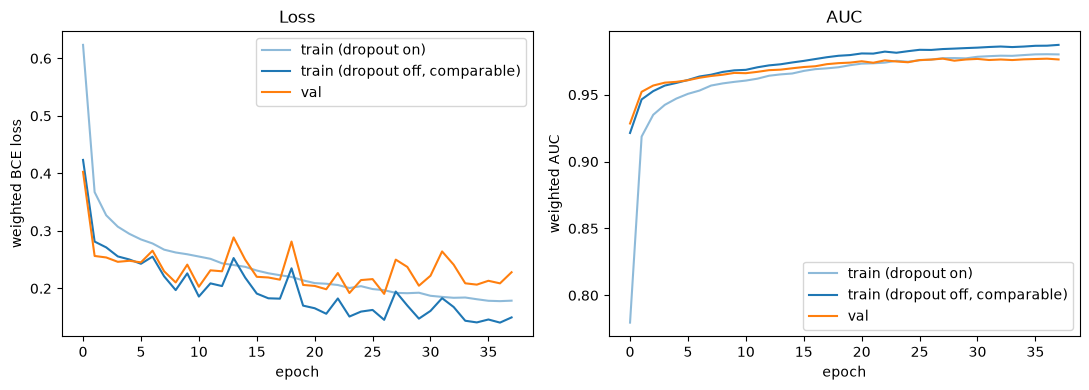

Final weighted AUC: train=0.9841 val=0.9770


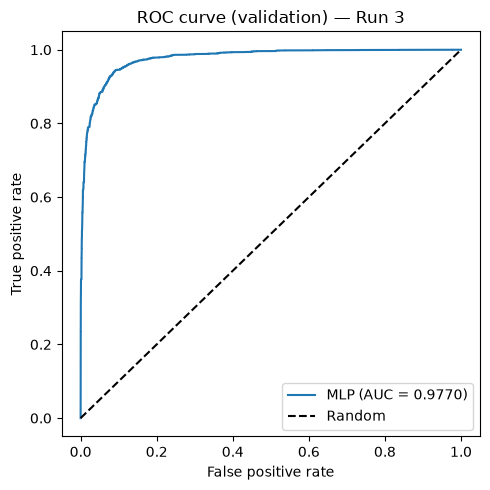

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_run3.eval()
with torch.no_grad():
    train_probs_run3 = torch.sigmoid(model_run3(X_train_t_run3)).cpu().numpy()
    val_probs_run3 = torch.sigmoid(model_run3(X_val_t_run3)).cpu().numpy()

auc_train_run3 = roc_auc_score(y_train_run3, train_probs_run3, sample_weight=np.abs(w_train_run3))
auc_val_run3 = roc_auc_score(y_val_run3, val_probs_run3, sample_weight=w_val_fit_run3)

print(f"Final weighted AUC: train={auc_train_run3:.4f} val={auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, val_probs_run3, sample_weight=w_val_fit_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"MLP (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Run 3

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9770


Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3ImportanceFull_DNN.png


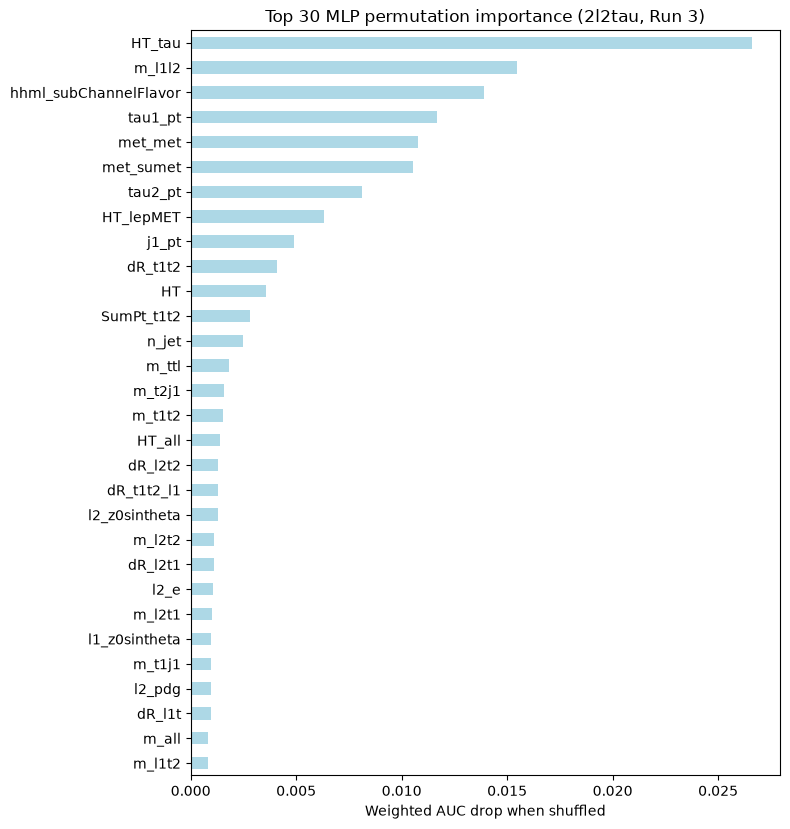

HT_tau                   0.026602
m_l1l2                   0.015445
hhml_subChannelFlavor    0.013916
tau1_pt                  0.011668
met_met                  0.010781
met_sumet                0.010524
tau2_pt                  0.008099
HT_lepMET                0.006327
j1_pt                    0.004882
dR_t1t2                  0.004105
HT                       0.003558
SumPt_t1t2               0.002829
n_jet                    0.002489
m_ttl                    0.001801
m_t2j1                   0.001581
Name: auc_drop, dtype: float64

In [91]:
importance_run3 = permutation_importance(model_run3, X_val_t_run3, y_val_t_run3, w_val_t_run3, features_run3, n_repeats=5)
PLOTS_DIR_R3 = BASE_DIR_RUN3 / "plots"
PLOTS_DIR_R3.mkdir(parents=True, exist_ok=True)
plot_importance_bar(importance_run3, top_n=30, title="Top 30 MLP permutation importance (2l2tau, Run 3)",
                     save_path=PLOTS_DIR_R3 / "Run3ImportanceFull_DNN.png")
importance_run3.head(15)

## Correlation Pruning & Retraining — Run 3

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on Run 3 inputs).

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationTop30_DNN.png


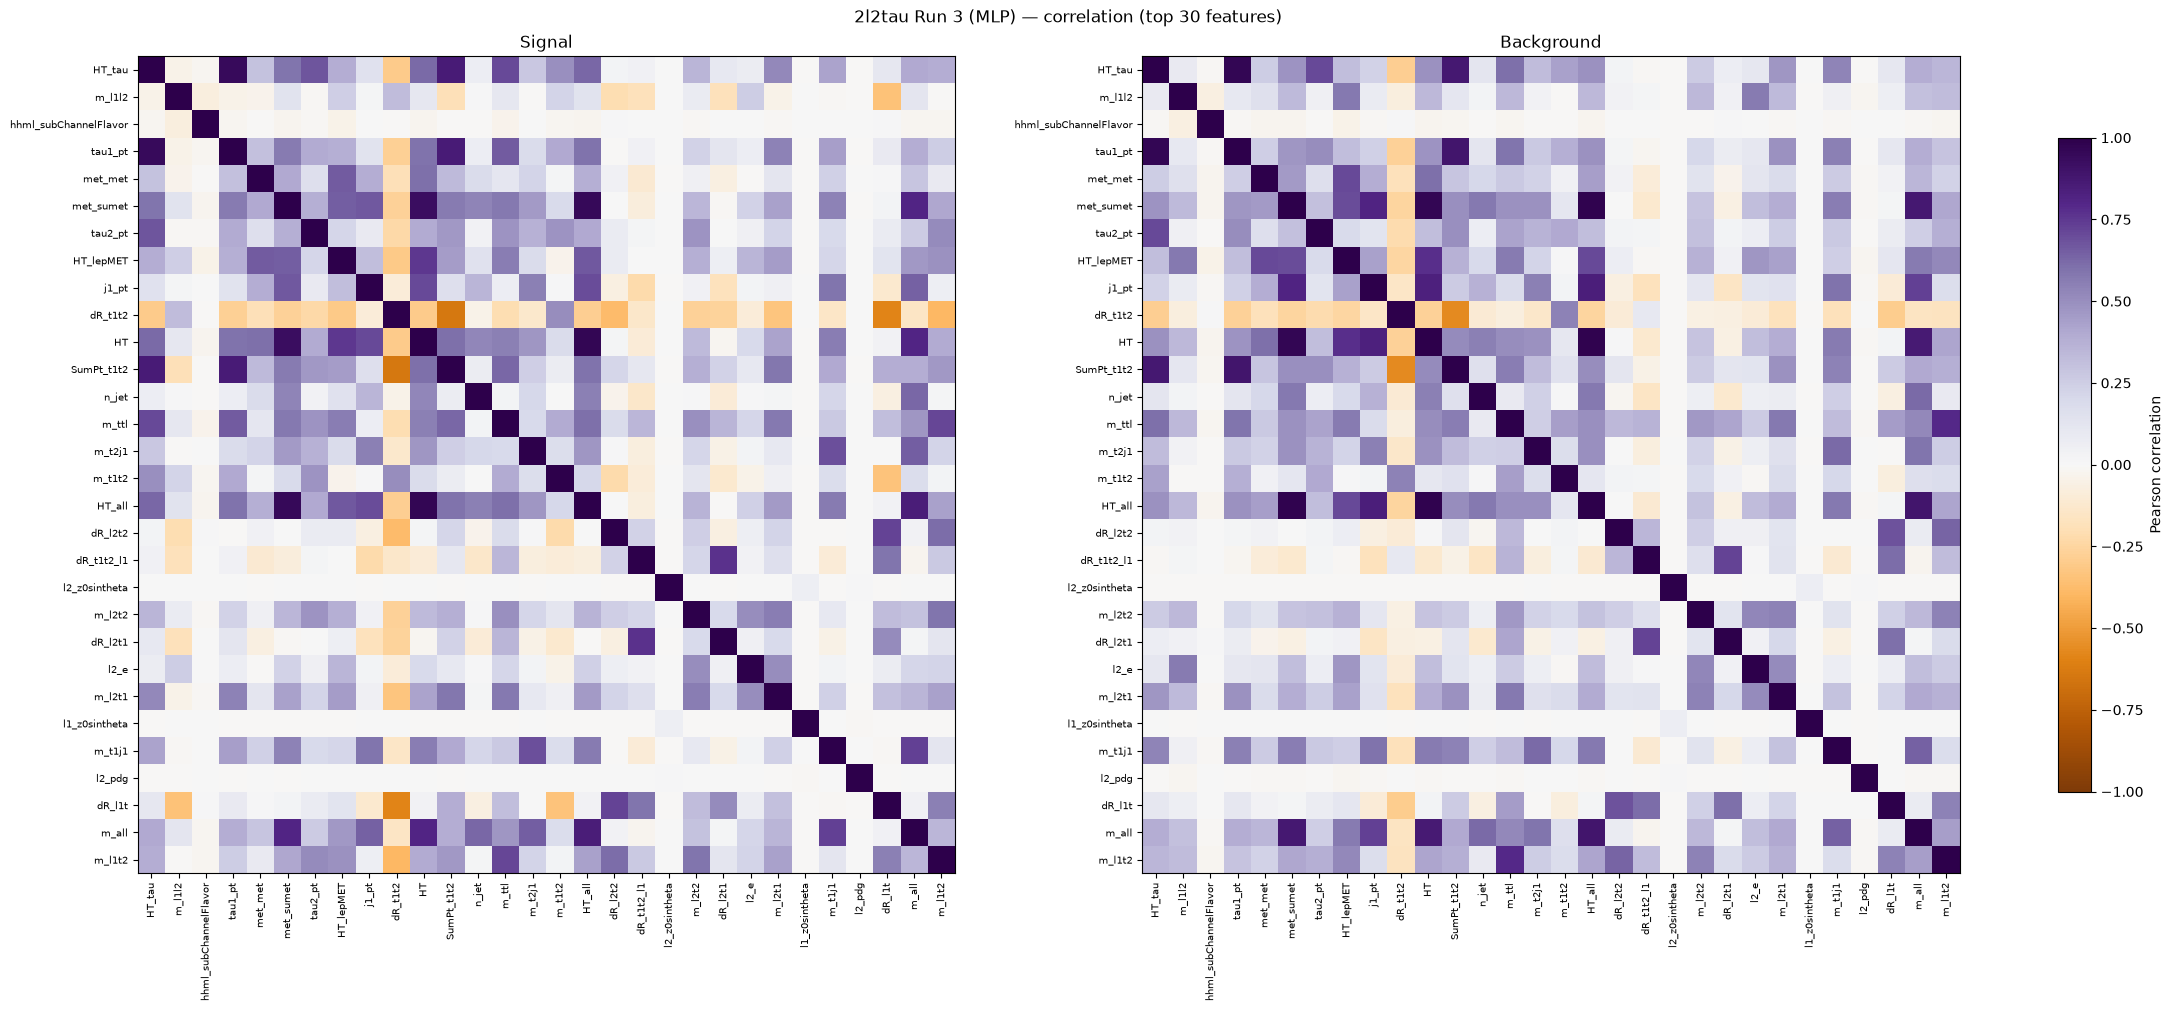

Pairs with |corr| > 0.50 (signal):
HT          HT_all        0.966258
met_sumet   HT_all        0.948978
HT_tau      tau1_pt       0.944058
met_sumet   HT            0.927185
tau1_pt     SumPt_t1t2    0.856141
HT_tau      SumPt_t1t2    0.855768
HT_all      m_all         0.846272
met_sumet   m_all         0.809805
HT          m_all         0.807370
dR_t1t2_l1  dR_l2t1       0.770571
HT_lepMET   HT            0.757550
m_t1j1      m_all         0.727481
dR_l2t2     dR_l1t        0.722181
m_ttl       m_l1t2        0.714319
j1_pt       HT            0.707830
HT_tau      m_ttl         0.705104

Pairs with |corr| > 0.50 (background):
HT          HT_all        0.980830
met_sumet   HT_all        0.976870
HT_tau      tau1_pt       0.966419
met_sumet   HT            0.963383
HT_all      m_all         0.889913
tau1_pt     SumPt_t1t2    0.884750
met_sumet   m_all         0.872929
HT_tau      SumPt_t1t2    0.870326
HT          m_all         0.863376
j1_pt       HT_all        0.837024
            HT 

In [92]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_run3 = importance_run3.index[:TOP_N_IMPORTANCE].tolist()
corrs_run3 = grouped_correlations(data_run3, top_feats_run3, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_run3[1], corrs_run3[0]], ["Signal", "Background"], top_feats_run3,
    suptitle=f"2l2tau Run 3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_run3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_run3[0]).to_string())

In [93]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------

corr_max_run3 = corrs_run3[1].abs().combine(corrs_run3[0].abs(), np.maximum)
PRUNED_FEATURES_run3, dropped_features_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. HT_tau
   2. m_l1l2
   3. hhml_subChannelFlavor
   4. met_met
   5. met_sumet
   6. tau2_pt
   7. HT_lepMET
   8. dR_t1t2
   9. n_jet
  10. m_ttl
  11. m_t2j1
  12. m_t1t2
  13. dR_l2t2
  14. dR_t1t2_l1
  15. l2_z0sintheta
  16. m_l2t2
  17. l2_e
  18. m_l2t1
  19. l1_z0sintheta
  20. m_t1j1

Dropped 6 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.966)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.819)
  HT              -> redundant with met_sumet       (|corr| = 0.963)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.870)
  HT_all          -> redundant with met_sumet       (|corr| = 0.977)
  dR_l2t1         -> redundant with dR_t1t2_l1      (|corr| = 0.771)


Full model      (81 features): train_auc_eval = 0.9841 | val_auc = 0.9770
Pruned model     (20 features): train_auc_eval = 0.9797 | val_auc = 0.9801
Baseline weighted AUC: 0.9801
Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3ImportancePruned_DNN.png


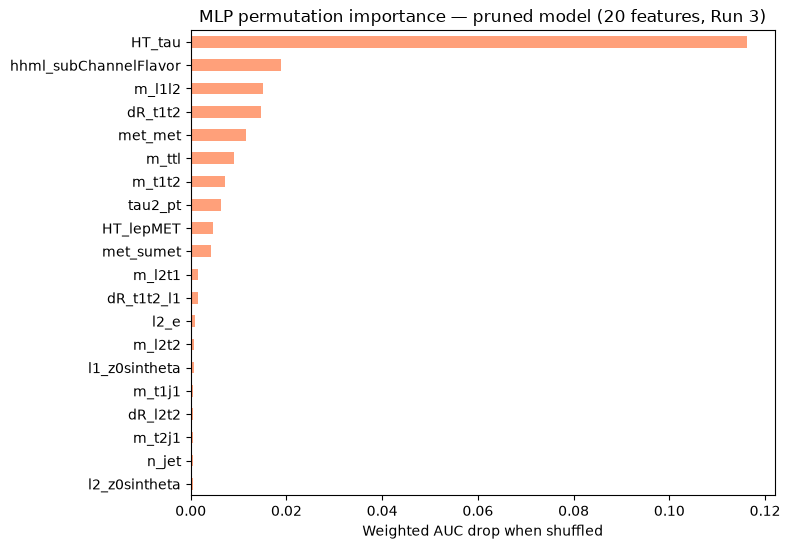

Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3CorrelationPruned_DNN.png


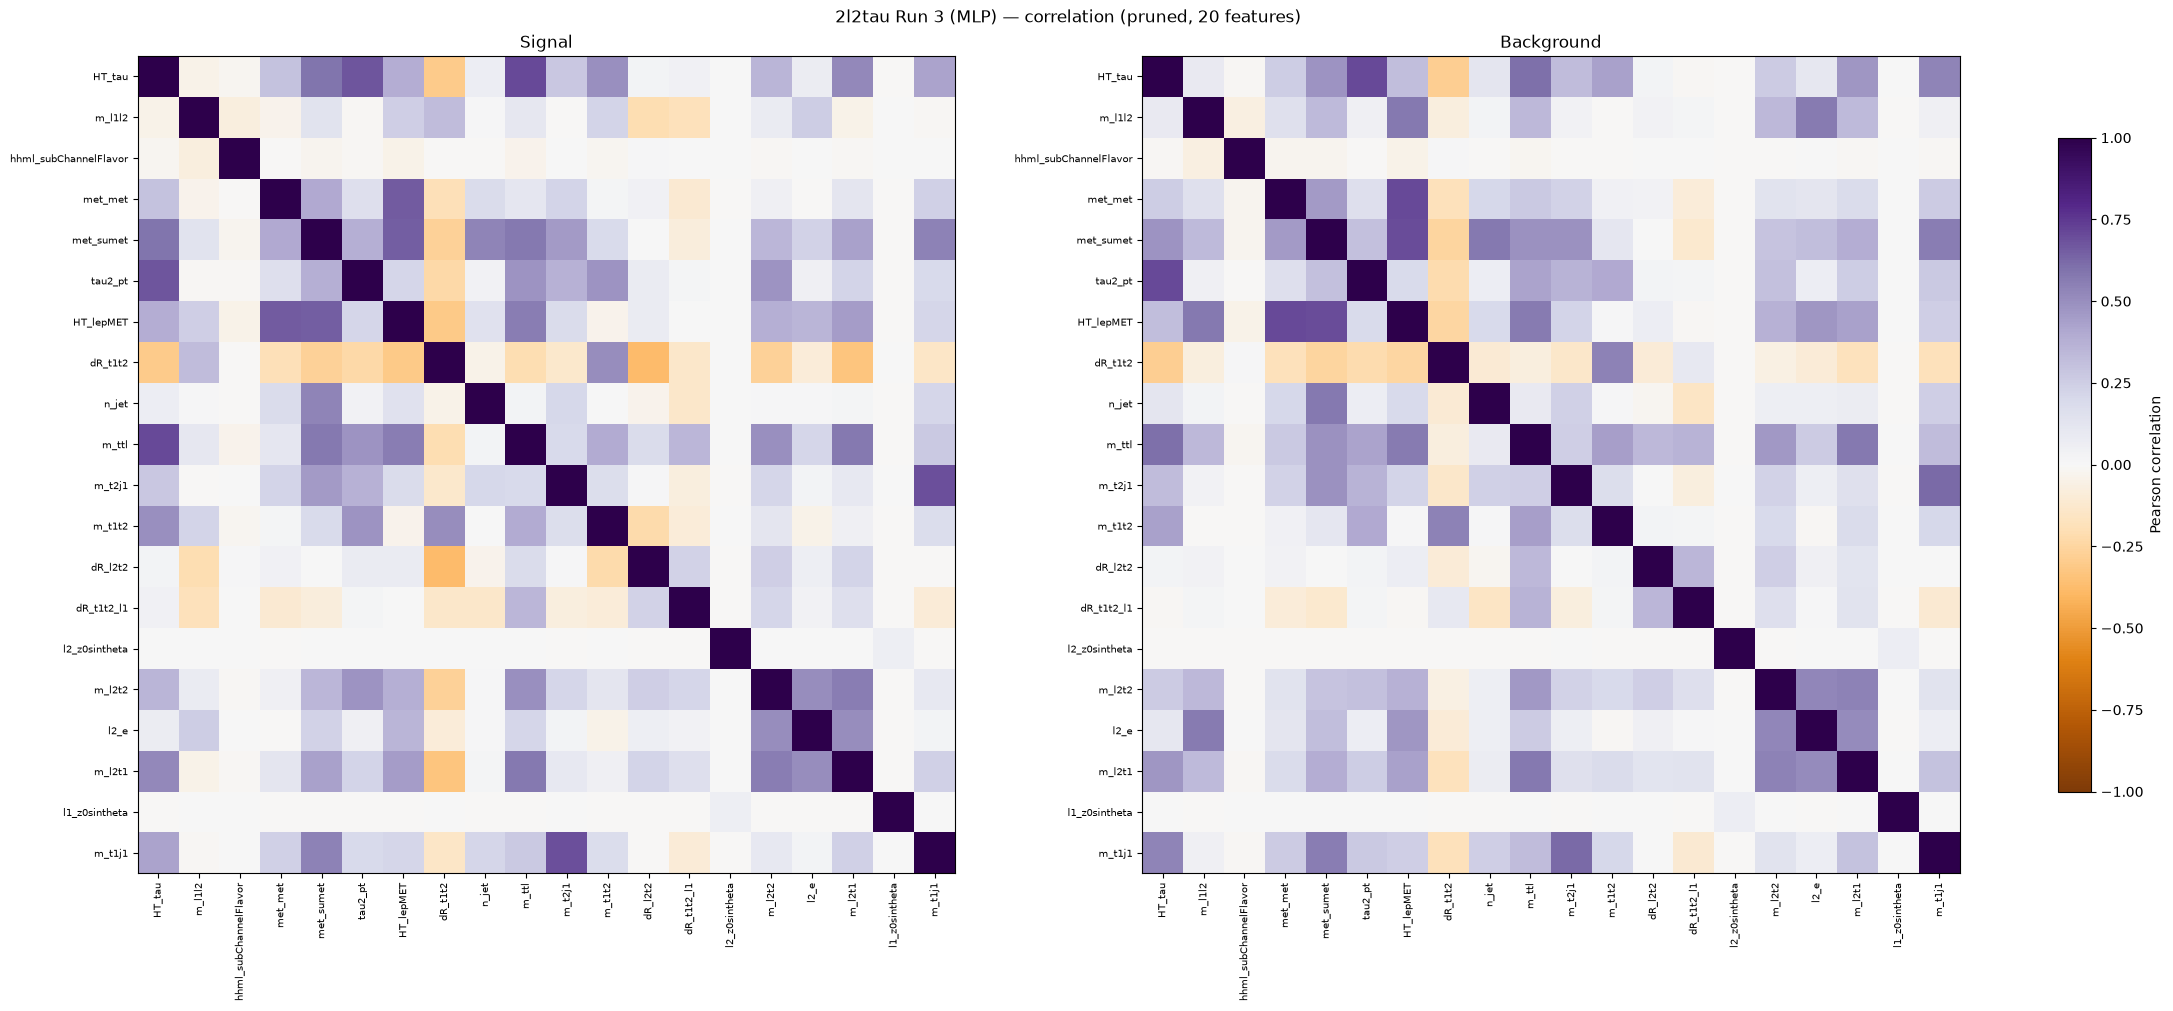

In [94]:
# ---- Retrain on the pruned feature set --------------------------------
def subset_feature_tensors_run3(feature_subset, all_features=features_run3):

    """
    Run 3 version of subset_feature_tensors: slices the already-scaled Run 3
    train/val numpy arrays (X_train_scaled_run3/X_val_scaled_run3) instead of
    the Run 2 globals, so Run 2's arrays are untouched.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t


X_train_pruned_t_run3, X_val_pruned_t_run3, X_test_pruned_t_run3 = subset_feature_tensors_run3(PRUNED_FEATURES_run3)

model_pruned_run3, history_pruned_run3, val_auc_pruned_run3, train_auc_pruned_run3, train_auc_eval_pruned_run3 = train_model(
    hidden_sizes=best_hidden_sizes_run3, verbose=False,
    X_train_data=X_train_pruned_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_pruned_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

print(f"Full model      ({len(features_run3):2d} features): train_auc_eval = {best_train_auc_eval_run3:.4f} | val_auc = {best_val_auc_run3:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_run3):2d} features): train_auc_eval = {train_auc_eval_pruned_run3:.4f} | val_auc = {val_auc_pruned_run3:.4f}")

importance_pruned_run3 = permutation_importance(model_pruned_run3, X_val_pruned_t_run3, y_val_t_run3, w_val_t_run3, PRUNED_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_pruned_run3, top_n=len(PRUNED_FEATURES_run3),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_run3)} features, Run 3)",
    color="lightsalmon",
    save_path=PLOTS_DIR_R3 / "Run3ImportancePruned_DNN.png",
)

pruned_corrs_run3 = grouped_correlations(data_run3, PRUNED_FEATURES_run3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_run3[1], pruned_corrs_run3[0]], ["Signal", "Background"], PRUNED_FEATURES_run3,
    suptitle=f"2l2tau Run 3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_run3)} features)",
    save_path=PLOTS_DIR_R3 / "Run3CorrelationPruned_DNN.png",
)

## Top-15 Features Only — Run 3

Kept 15 decorrelated features (most -> least important):
   1. HT_tau
   2. m_l1l2
   3. hhml_subChannelFlavor
   4. met_met
   5. met_sumet
   6. tau2_pt
   7. HT_lepMET
   8. dR_t1t2
   9. n_jet
  10. m_ttl
  11. m_t2j1
  12. m_t1t2
  13. dR_l2t2
  14. dR_t1t2_l1
  15. l2_z0sintheta

Dropped 5 redundant features (|corr| > 0.75 with a more important feature):
  tau1_pt         -> redundant with HT_tau          (|corr| = 0.966)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.819)
  HT              -> redundant with met_sumet       (|corr| = 0.963)
  SumPt_t1t2      -> redundant with HT_tau          (|corr| = 0.870)
  HT_all          -> redundant with met_sumet       (|corr| = 0.977)


Baseline weighted AUC: 0.9799
Saved plot -> PPSSP_2026/2l2tau/run3/plots/Run3ImportanceTop15_DNN.png


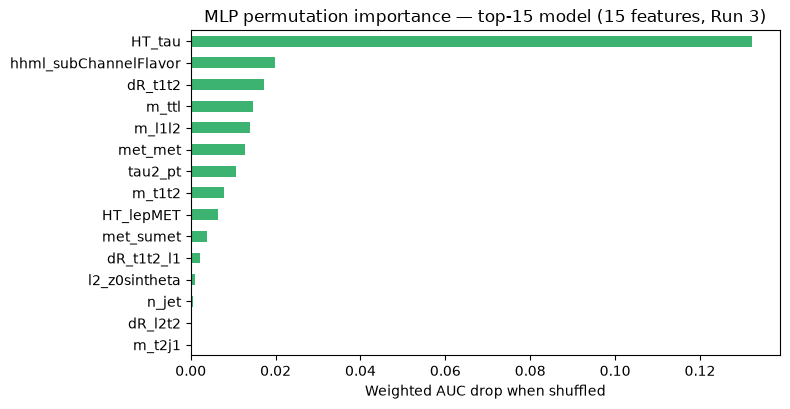


Weighted train(eval-mode)/validation AUC comparison (Run 3):


,model,train_auc_eval,val_auc
1,Pruned (20 features),0.979690,0.980117
2,Top-15 (15 features),0.978040,0.979950
0,Full (81 features),0.984135,0.976984


In [95]:
TOP15_FEATURES_run3, dropped_top15_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, n_keep=15)

X_train_top15_t_run3, X_val_top15_t_run3, X_test_top15_t_run3 = subset_feature_tensors_run3(TOP15_FEATURES_run3)

model_top15_run3, history_top15_run3, val_auc_top15_run3, train_auc_top15_run3, train_auc_eval_top15_run3 = train_model(
    hidden_sizes=best_hidden_sizes_run3, verbose=False,
    X_train_data=X_train_top15_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_top15_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

importance_top15_run3 = permutation_importance(model_top15_run3, X_val_top15_t_run3, y_val_t_run3, w_val_t_run3, TOP15_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_top15_run3, top_n=len(TOP15_FEATURES_run3),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_run3)} features, Run 3)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_R3 / "Run3ImportanceTop15_DNN.png",
)

comparison_run3 = pd.DataFrame([
    {"model": f"Full ({len(features_run3)} features)", "train_auc_eval": best_train_auc_eval_run3, "val_auc": best_val_auc_run3},
    {"model": f"Pruned ({len(PRUNED_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_pruned_run3, "val_auc": val_auc_pruned_run3},
    {"model": f"Top-15 ({len(TOP15_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_top15_run3, "val_auc": val_auc_top15_run3},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Run 3):")
comparison_run3

## Physics Figure of Merit & Final Summary — Run 3

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to Run 3's
held-out TEST partition.


In [96]:
# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the Run 3 pruning walk above. The score CUT
# is selected here by scanning VAL only - it is applied FROZEN to test in the
# "Held-Out Test Evaluation" cell below, never re-scanned there.
models_registry_run3 = {
    f"Full ({len(features_run3)} features)": (model_run3, X_val_t_run3, X_test_t_run3),
    f"Pruned ({len(PRUNED_FEATURES_run3)} features)": (model_pruned_run3, X_val_pruned_t_run3, X_test_pruned_t_run3),
    f"Top-15 ({len(TOP15_FEATURES_run3)} features)": (model_top15_run3, X_val_top15_t_run3, X_test_top15_t_run3),
}
best_name_run3 = f"Top-15 ({len(TOP15_FEATURES_run3)} features)"

final_model_run3, X_val_final_t_run3, X_test_final_t_run3 = models_registry_run3[best_name_run3]

final_model_run3.eval()
with torch.no_grad():
    val_scores_run3 = torch.sigmoid(final_model_run3(X_val_final_t_run3)).cpu().numpy()

z_val_run3, thr_val_run3 = significance_scan(y_val_run3, val_scores_run3, w_val_run3)  # signed w_phys - expected yields
final_val_auc_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "val_auc"].iloc[0]
final_train_auc_eval_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name_run3}")
print(f"Weighted val AUC = {final_val_auc_run3:.4f}")
print(f"Max Asimov Z (val) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9799
Max Asimov Z (val) = 0.023 at score cut = 0.9781


### Held-Out Test Evaluation (Run 3)

`X_test_final_t_run3`/`y_test_run3`/`w_test_run3` have not participated in
anything above. This is the one place they are read: the final model is
scored once, and the VAL-selected score cut is applied frozen.


In [97]:
# ---- HELD-OUT TEST EVALUATION (Run 3) — scored EXACTLY ONCE ----------------
# X_test_final_t_run3/y_test_run3/w_test_run3 have not been touched anywhere
# above - this is the only cell in the Run 3 section that reads them. The
# score cut `thr_val_run3` was chosen by scanning VAL only; it is applied
# here FROZEN, NOT re-scanned on test.

final_model_run3.eval()
with torch.no_grad():
    test_scores_run3 = torch.sigmoid(final_model_run3(X_test_final_t_run3)).cpu().numpy()

auc_test_run3 = roc_auc_score(y_test_run3, test_scores_run3, sample_weight=w_test_fit_run3)

S_test_run3 = w_test_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 1)].sum()
B_test_run3 = w_test_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 0)].sum()
z_test_run3 = (np.sqrt(2 * ((S_test_run3 + B_test_run3) * np.log(1 + S_test_run3 / B_test_run3) - S_test_run3))
               if (S_test_run3 > 0 and B_test_run3 > 0) else np.nan)

print(f"Final model: {best_name_run3}")
print(f"Weighted AUC: val = {final_val_auc_run3:.4f}  |  test (held-out, scored once) = {auc_test_run3:.4f}")
print(f"At the VAL-selected score cut = {thr_val_run3:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_run3:.2f} | test B = {B_test_run3:.2f} | test Z = {z_test_run3:.3f}  (val Z was {z_val_run3:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9799  |  test (held-out, scored once) = 0.9765
At the VAL-selected score cut = 0.9781 (frozen, NOT re-scanned on test):
  test S = 0.02 | test B = 1.49 | test Z = 0.020  (val Z was 0.023)


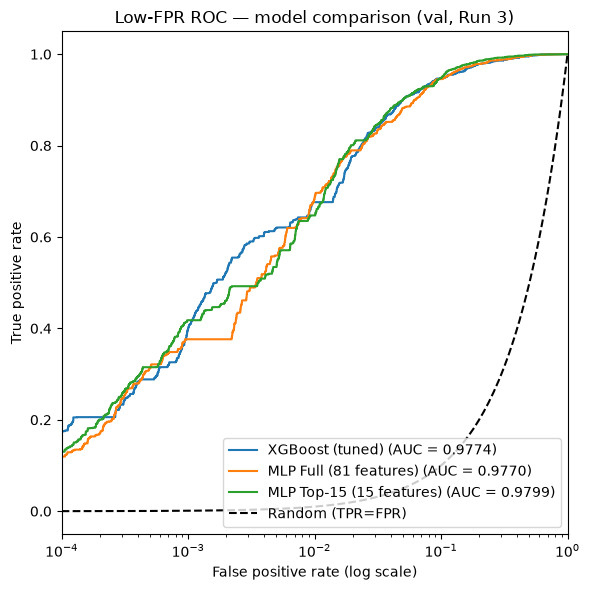

--- FPR = 1e-03 (~13 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.3991  (399x random lift)
  MLP Full (81 features)           TPR = 0.3762  (376x random lift)
  MLP Top-15 (15 features)         TPR = 0.4179  (418x random lift)
--- FPR = 1e-02 (~129 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.6763  (68x random lift)
  MLP Full (81 features)           TPR = 0.6840  (68x random lift)
  MLP Top-15 (15 features)         TPR = 0.6472  (65x random lift)


In [98]:
# ---- Load the tuned XGBoost model for the same 2l2tau Run 3 track, for an
# apples-to-apples overlay. val_df_run3 here is Run 3's own holdout split.

import xgboost as xgb

xgb_model_run3 = xgb.XGBClassifier()
xgb_model_run3.load_model(BASE_DIR_RUN3 / "final_model_run3.json")
with open(BASE_DIR_RUN3 / "optuna_features_run3.json") as f:
    xgb_features_run3 = json.load(f)

xgb_val_scores_run3 = xgb_model_run3.predict_proba(val_df_run3[xgb_features_run3])[:, 1]

# ROC curve for the FINAL model (top-15 pruned, `val_scores_run3` from the
# significance-scan cell above), not the full model - matches the `best_name_run3` label.
fpr_val_run3, tpr_val_run3, _ = roc_curve(y_val_run3, val_scores_run3, sample_weight=w_val_fit_run3)

curves_run3 = {
    "XGBoost (tuned)": roc_with_auc(y_val_run3, xgb_val_scores_run3, w_val_fit_run3),
    f"MLP Full ({len(features_run3)} features)": roc_with_auc(y_val_run3, val_probs_run3, w_val_fit_run3),
    f"MLP {best_name_run3}": (fpr_val_run3, tpr_val_run3, final_val_auc_run3),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_run3.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Run 3)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_run3 = int((y_val_run3 == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_run3:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_run3.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert np.isfinite(X_train_scaled_run3).all() and np.isfinite(X_val_scaled_run3).all() and np.isfinite(X_test_scaled_run3).all(), \
    "NaN/inf reached the model input (Run 3)"

# Determinism check, same convention as the Run 2 section.
set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED: {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test_run3, z_test_run3 at the
# frozen, VAL-selected score cut).

summary_run3 = pd.DataFrame([{
    "model": best_name_run3,
    "train_auc_eval": final_train_auc_eval_run3,
    "val_auc": final_val_auc_run3,
    "max_asimov_Z (val)": z_val_run3,
    "test_auc (held-out, scored once)": auc_test_run3,
    "test_Z_at_val_cut (held-out)": z_test_run3,
}])

print("\nFinal summary (MLP, 2l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3


Determinism check passed: two re-seeded runs give identical val_auc = 0.962746

Final summary (MLP, 2l2tau Run 3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.979224 0.981916            0.028067                          0.978142                       0.02221


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.979224,0.981916,0.028067,0.978142,0.02221


## Run 2 + Run 3 — Combined Track

Chains (concatenates) Run 2 and Run 3 events into a single training sample,
mirroring `2L2Tau_Master_Pipeline.ipynb`'s Section 5. The candidate feature
set is restricted to branches common to BOTH runs (the intersection of
`features_run2` and `features_run3`, equivalent to discovering common
branches across all process files in both directories). An extra `run`
bookkeeping column (2 or 3) is kept (never a training feature) so the
Run2/Run3 mix can be checked, and so the train/val split can be stratified
on `label` AND `run` jointly. Everything below uses `_comb`-suffixed
variable names so the Run 2 and Run 3 results above remain untouched.

In [99]:
# Combined uses features common to BOTH runs (equivalent to discovering
# common branches across all process files in both directories).

candidate_features_comb = sorted(set(features_run2) & set(features_run3))

keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process"]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

for run_label in (2, 3):
    sub = data_comb[data_comb["run"] == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

Dropped 0 constant/empty features:
  []

81 final features
Total: 324510 events | signal = 137905 | background = 186605
Yield (w_phys): signal = 0.91 | background = 3160.25

Combined: 324510 events, 81 features (intersection of Run2's 81 and Run3's 81)
Run 2: signal yield = 0.42 | background yield = 1034.16 | n_events = 94968
Run 3: signal yield = 0.49 | background yield = 2126.09 | n_events = 229542


## Sentinel Audit (-1) — Combined

Same diagnostic as the Run 2/Run 3 sections above, run on the combined
sample.

In [ ]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)
if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504625                      2.0
l2_charge         0.495375                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing — Combined

Same 80/10/10 `make_3way_split`, but stratified on `label` AND `run` jointly
(not just `label`) so all three partitions keep the same Run2/Run3 mix -
passed via `extra_stratify_col="run"`. TEST is held out (persisted + never
used for imputation/scaling/pruning/tuning/early stopping) the same way as
the Run 2/Run 3 sections. Preprocessing (median imputation, standard
scaling, `__isnan` flags) otherwise follows the same convention.


In [100]:
train_df_comb, val_df_comb, test_df_comb = make_3way_split(data_comb, extra_stratify_col="run")

BASE_DIR_COMB = Path("PPSSP_2026/2l2tau/combined")
SPLIT_DIR_COMB = BASE_DIR_COMB / "splits"
persist_test_partition(test_df_comb, SPLIT_DIR_COMB)

X_train_raw_comb, y_train_comb, w_train_comb = train_df_comb[features_comb], train_df_comb["label"].to_numpy(), train_df_comb["w_phys"].to_numpy()
X_val_raw_comb,   y_val_comb,   w_val_comb   = val_df_comb[features_comb],   val_df_comb["label"].to_numpy(),   val_df_comb["w_phys"].to_numpy()
X_test_raw_comb,  y_test_comb,  w_test_comb  = test_df_comb[features_comb],  test_df_comb["label"].to_numpy(),  test_df_comb["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train_comb = X_train_raw_comb.isna()
flag_cols_comb = nan_train_comb.columns[nan_train_comb.any()].tolist()


def make_flags_comb(X_raw):
    """Combined-track version of make_flags: 0/1 missingness flags for `flag_cols_comb`."""
    f = X_raw[flag_cols_comb].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols_comb]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians_comb = X_train_raw_comb.median()
X_train_imp_comb = X_train_raw_comb.fillna(train_medians_comb)
X_val_imp_comb = X_val_raw_comb.fillna(train_medians_comb)
X_test_imp_comb = X_test_raw_comb.fillna(train_medians_comb)

scaler_comb = StandardScaler()
X_train_scaled_comb = np.hstack([scaler_comb.fit_transform(X_train_imp_comb), make_flags_comb(X_train_raw_comb).to_numpy()])
X_val_scaled_comb = np.hstack([scaler_comb.transform(X_val_imp_comb), make_flags_comb(X_val_raw_comb).to_numpy()])
X_test_scaled_comb = np.hstack([scaler_comb.transform(X_test_imp_comb), make_flags_comb(X_test_raw_comb).to_numpy()])

assert np.isfinite(X_train_scaled_comb).all(), "NaN/inf reached the model input (train, Combined)"
assert np.isfinite(X_val_scaled_comb).all(), "NaN/inf reached the model input (val, Combined)"
assert np.isfinite(X_test_scaled_comb).all(), "NaN/inf reached the model input (test, Combined)"

print(f"\n{len(flag_cols_comb)} features had missing values in train -> added {len(flag_cols_comb)} __isnan flag "
      f"columns (final input width = {X_train_scaled_comb.shape[1]} = {len(features_comb)} features + {len(flag_cols_comb)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.
w_train_fit_comb = make_fit_weights(y_train_comb, np.abs(w_train_comb))
w_train_abs_comb = np.abs(w_train_comb)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit_comb = np.abs(w_val_comb)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end.
w_test_fit_comb = np.abs(w_test_comb)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train_comb[y_train_comb==0]).sum() / np.abs(w_train_comb[y_train_comb==1]).sum():.1f}")


Train:   259607 events | signal =  110323 (yield=      0.73) | background =  149284 (yield=   2563.46) | signal weight scale factor = 3527.6
       run mix: {2: 75974, 3: 183633}
Val  :    32452 events | signal =   13791 (yield=      0.09) | background =   18661 (yield=    295.44) | signal weight scale factor = 3279.1
       run mix: {2: 9497, 3: 22955}
Test :    32451 events | signal =   13791 (yield=      0.09) | background =   18660 (yield=    301.35) | signal weight scale factor = 3299.4
       run mix: {2: 9497, 3: 22954}
  cross-check OK: PPSSP_2026/2l2tau/combined/splits/test.root test partition matches on 82 shared columns (32451 rows)
Wrote 32451 test events -> PPSSP_2026/2l2tau/combined/splits/test.root  (held out until final evaluation)

28 features had missing values in train -> added 28 __isnan flag columns (final input width = 109 = 81 features + 28 flags)
Signal weight scale factor (train): 4254.1


## PyTorch Dataset & Model — Combined

In [101]:
X_train_t_comb = torch.tensor(X_train_scaled_comb, dtype=torch.float32, device=DEVICE)
y_train_t_comb = torch.tensor(y_train_comb, dtype=torch.float32, device=DEVICE)
w_train_t_comb = torch.tensor(w_train_fit_comb, dtype=torch.float32, device=DEVICE)
w_train_abs_t_comb = torch.tensor(w_train_abs_comb, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t_comb = torch.tensor(X_val_scaled_comb, dtype=torch.float32, device=DEVICE)
y_val_t_comb = torch.tensor(y_val_comb, dtype=torch.float32, device=DEVICE)
w_val_t_comb = torch.tensor(w_val_fit_comb, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section.
X_test_t_comb = torch.tensor(X_test_scaled_comb, dtype=torch.float32, device=DEVICE)
y_test_t_comb = torch.tensor(y_test_comb, dtype=torch.float32, device=DEVICE)
w_test_t_comb = torch.tensor(w_test_fit_comb, dtype=torch.float32, device=DEVICE)

model_comb = build_model(n_features=X_train_scaled_comb.shape[1])

print(model_comb)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=109, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Combined

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_comb` tensors passed in so the Run 2/Run 3
models/histories are untouched.

In [102]:
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    hidden_sizes=DEFAULT_HIDDEN_SIZES,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")

Epoch   1 | train_loss=0.5908 val_loss=0.2566 | train_auc=0.7849 train_auc_eval=0.9256 val_auc=0.9239
Epoch   2 | train_loss=0.3580 val_loss=0.2371 | train_auc=0.9216 train_auc_eval=0.9480 val_auc=0.9460
Epoch   3 | train_loss=0.3198 val_loss=0.2839 | train_auc=0.9375 train_auc_eval=0.9536 val_auc=0.9509
Epoch   4 | train_loss=0.2983 val_loss=0.2796 | train_auc=0.9461 train_auc_eval=0.9578 val_auc=0.9534
Epoch   5 | train_loss=0.2851 val_loss=0.2969 | train_auc=0.9510 train_auc_eval=0.9608 val_auc=0.9560
Epoch   6 | train_loss=0.2734 val_loss=0.2621 | train_auc=0.9547 train_auc_eval=0.9629 val_auc=0.9574
Epoch   7 | train_loss=0.2706 val_loss=0.2846 | train_auc=0.9558 train_auc_eval=0.9647 val_auc=0.9588
Epoch   8 | train_loss=0.2653 val_loss=0.2464 | train_auc=0.9575 train_auc_eval=0.9666 val_auc=0.9591
Epoch   9 | train_loss=0.2571 val_loss=0.2925 | train_auc=0.9600 train_auc_eval=0.9684 val_auc=0.9610
Epoch  10 | train_loss=0.2543 val_loss=0.2944 | train_auc=0.9609 train_auc_eval=0.

Epoch  20 | train_loss=0.2118 val_loss=0.2724 | train_auc=0.9727 train_auc_eval=0.9803 val_auc=0.9701
Epoch  21 | train_loss=0.2083 val_loss=0.2336 | train_auc=0.9735 train_auc_eval=0.9805 val_auc=0.9698
Epoch  22 | train_loss=0.2062 val_loss=0.2831 | train_auc=0.9739 train_auc_eval=0.9812 val_auc=0.9709
Epoch  23 | train_loss=0.2049 val_loss=0.3009 | train_auc=0.9743 train_auc_eval=0.9817 val_auc=0.9699
Epoch  24 | train_loss=0.2029 val_loss=0.2629 | train_auc=0.9748 train_auc_eval=0.9822 val_auc=0.9713
Epoch  25 | train_loss=0.1964 val_loss=0.2541 | train_auc=0.9763 train_auc_eval=0.9830 val_auc=0.9725
Epoch  26 | train_loss=0.1961 val_loss=0.2296 | train_auc=0.9764 train_auc_eval=0.9829 val_auc=0.9722
Epoch  27 | train_loss=0.1956 val_loss=0.2383 | train_auc=0.9764 train_auc_eval=0.9833 val_auc=0.9718
Epoch  28 | train_loss=0.1915 val_loss=0.2385 | train_auc=0.9774 train_auc_eval=0.9841 val_auc=0.9722
Epoch  29 | train_loss=0.1920 val_loss=0.2653 | train_auc=0.9774 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Combined

In [ ]:
search_results_comb = []
best_search_auc_comb, best_hidden_sizes_comb = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(
        hidden_sizes=hidden_sizes, verbose=False,
        X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
        X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
        w_train_eval_data=w_train_abs_t_comb,
    )
    search_results_comb.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc_comb:
        best_search_auc_comb, best_hidden_sizes_comb = trial_val_auc, hidden_sizes
        model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes_comb} | val_auc={best_search_auc_comb:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9740 val_auc=0.9745
hidden_sizes=(128, 64)        -> train_auc=0.9782 val_auc=0.9763
hidden_sizes=(256, 128)       -> train_auc=0.9821 val_auc=0.9770
hidden_sizes=(128, 64, 32)    -> train_auc=0.9777 val_auc=0.9760
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9823 val_auc=0.9765

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9770


## Evaluation — Combined

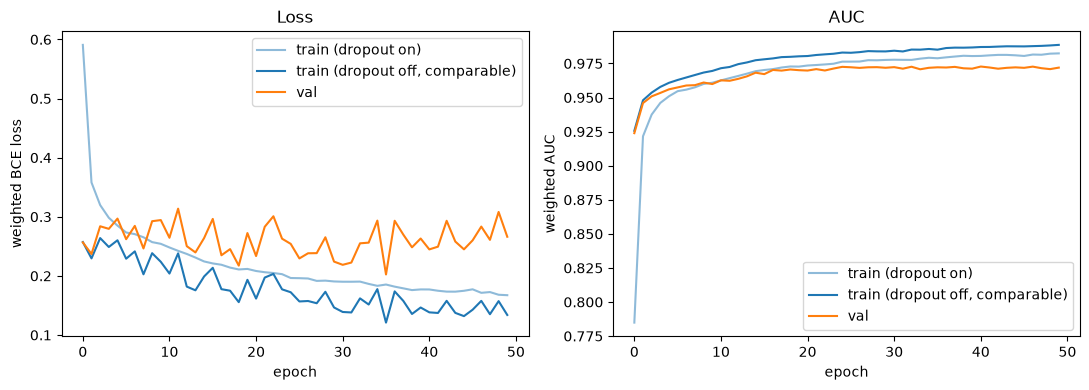

Final weighted AUC: train=0.9871 val=0.9728


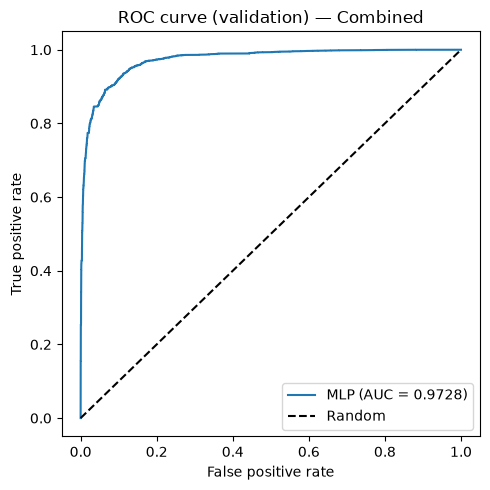

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_comb.eval()
with torch.no_grad():
    train_probs_comb = torch.sigmoid(model_comb(X_train_t_comb)).cpu().numpy()
    val_probs_comb = torch.sigmoid(model_comb(X_val_t_comb)).cpu().numpy()

auc_train_comb = roc_auc_score(y_train_comb, train_probs_comb, sample_weight=np.abs(w_train_comb))
auc_val_comb = roc_auc_score(y_val_comb, val_probs_comb, sample_weight=w_val_fit_comb)

print(f"Final weighted AUC: train={auc_train_comb:.4f} val={auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, val_probs_comb, sample_weight=w_val_fit_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"MLP (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Combined")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Combined

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9728


Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedImportanceFull_DNN.png


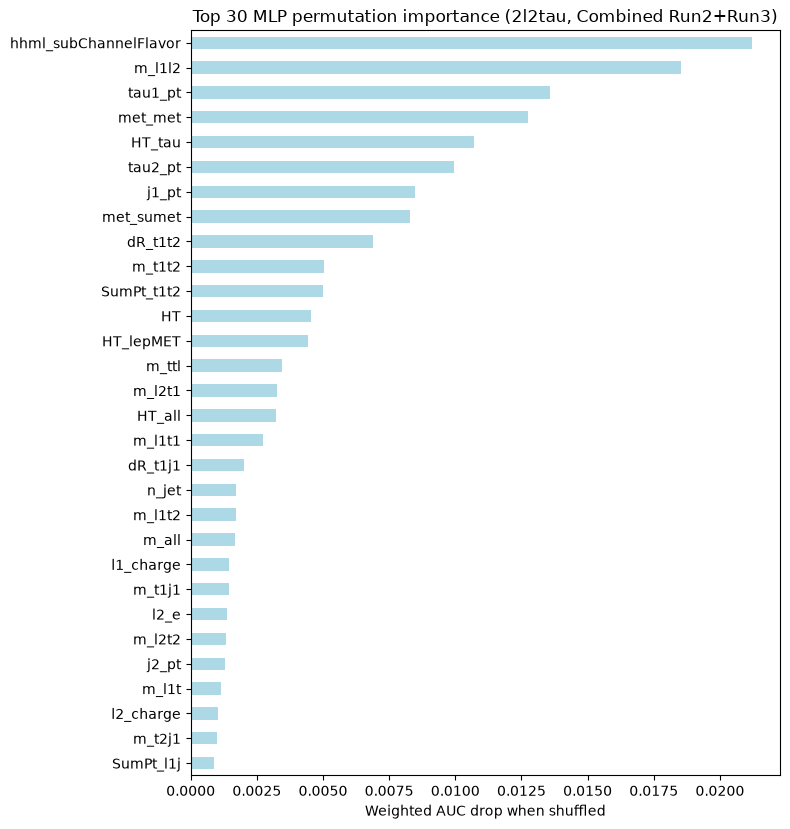

hhml_subChannelFlavor    0.021210
m_l1l2                   0.018515
tau1_pt                  0.013581
met_met                  0.012731
HT_tau                   0.010716
tau2_pt                  0.009950
j1_pt                    0.008480
met_sumet                0.008288
dR_t1t2                  0.006905
m_t1t2                   0.005041
SumPt_t1t2               0.004990
HT                       0.004539
HT_lepMET                0.004420
m_ttl                    0.003451
m_l2t1                   0.003243
Name: auc_drop, dtype: float64

In [104]:
importance_comb = permutation_importance(model_comb, X_val_t_comb, y_val_t_comb, w_val_t_comb, features_comb, n_repeats=5)
PLOTS_DIR_COMB = BASE_DIR_COMB / "plots"
PLOTS_DIR_COMB.mkdir(parents=True, exist_ok=True)
plot_importance_bar(importance_comb, top_n=30, title="Top 30 MLP permutation importance (2l2tau, Combined Run2+Run3)",
                     save_path=PLOTS_DIR_COMB / "CombinedImportanceFull_DNN.png")
importance_comb.head(15)

## Correlation Pruning & Retraining — Combined

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on the combined inputs).

Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedCorrelationTop30_DNN.png


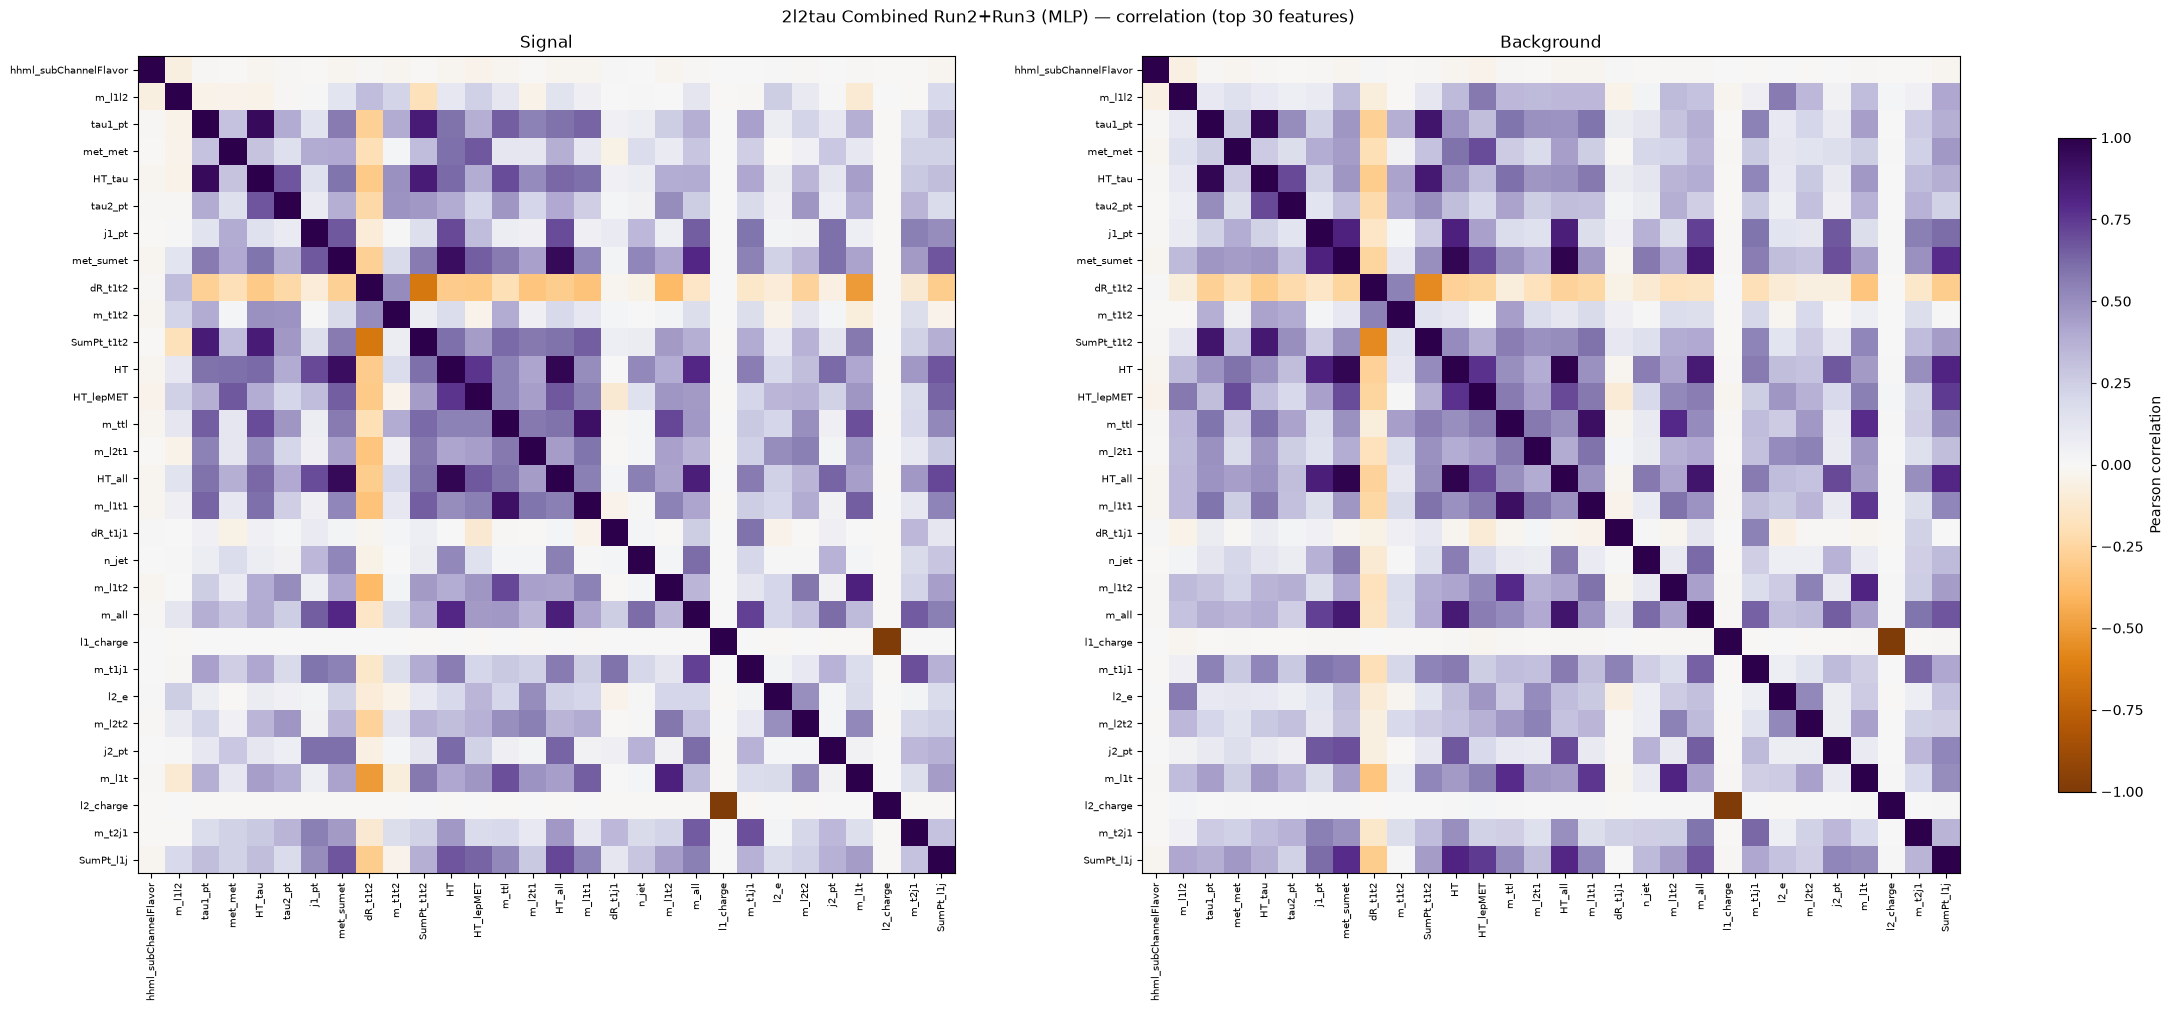

Pairs with |corr| > 0.50 (signal):
l1_charge  l2_charge     1.000000
HT         HT_all        0.965874
met_sumet  HT_all        0.947001
tau1_pt    HT_tau        0.944320
met_sumet  HT            0.925654
m_ttl      m_l1t1        0.907596
tau1_pt    SumPt_t1t2    0.856576
HT_tau     SumPt_t1t2    0.855870
HT_all     m_all         0.836795
m_l1t2     m_l1t         0.833203
met_sumet  m_all         0.800901
HT         m_all         0.798775
           HT_lepMET     0.758184
m_all      m_t1j1        0.729315
m_ttl      m_l1t2        0.716849
HT_all     SumPt_l1j     0.713511
j1_pt      HT            0.709340

Pairs with |corr| > 0.50 (background):
l1_charge  l2_charge     1.000000
HT         HT_all        0.981609
met_sumet  HT_all        0.977666
tau1_pt    HT_tau        0.966115
met_sumet  HT            0.964556
m_ttl      m_l1t1        0.918735
HT_all     m_all         0.889782
tau1_pt    SumPt_t1t2    0.884395
met_sumet  m_all         0.872759
HT_tau     SumPt_t1t2    0.870378
HT     

In [105]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_comb = importance_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(data_comb, top_feats_comb, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"2l2tau Combined Run2+Run3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationTop30_DNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

In [106]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_comb, dropped_features_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. hhml_subChannelFlavor
   2. m_l1l2
   3. tau1_pt
   4. met_met
   5. tau2_pt
   6. j1_pt
   7. dR_t1t2
   8. m_t1t2
   9. HT_lepMET
  10. m_ttl
  11. m_l2t1
  12. dR_t1j1
  13. n_jet
  14. m_all
  15. l1_charge
  16. m_t1j1
  17. l2_e
  18. m_l2t2
  19. j2_pt
  20. m_t2j1

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.966)
  met_sumet       -> redundant with j1_pt           (|corr| = 0.821)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.884)
  HT              -> redundant with j1_pt           (|corr| = 0.830)
  HT_all          -> redundant with j1_pt           (|corr| = 0.838)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.919)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.789)
  m_l1t           -> redundant with m_ttl           (|corr| = 0.782)
  l2_charge       -> redundant with

Full model      (81 features): train_auc_eval = 0.9871 | val_auc = 0.9728
Pruned model     (20 features): train_auc_eval = 0.9796 | val_auc = 0.9763
Baseline weighted AUC: 0.9763
Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedImportancePruned_DNN.png


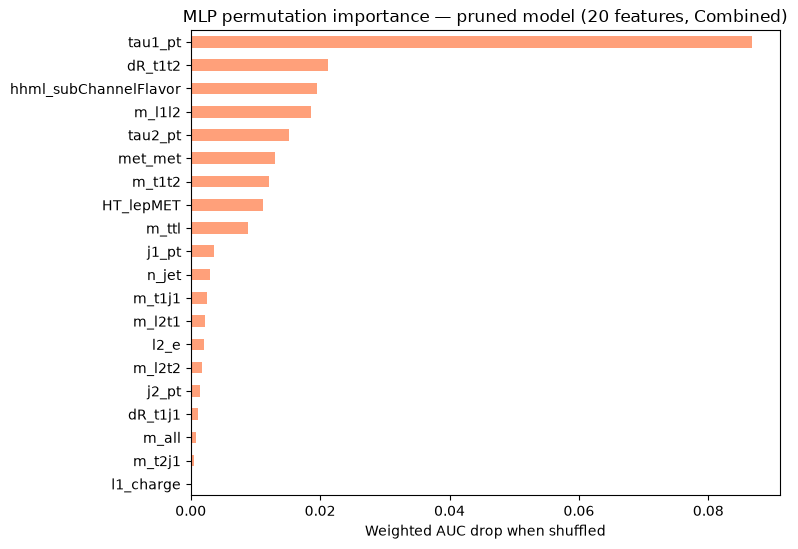

Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedCorrelationPruned_DNN.png


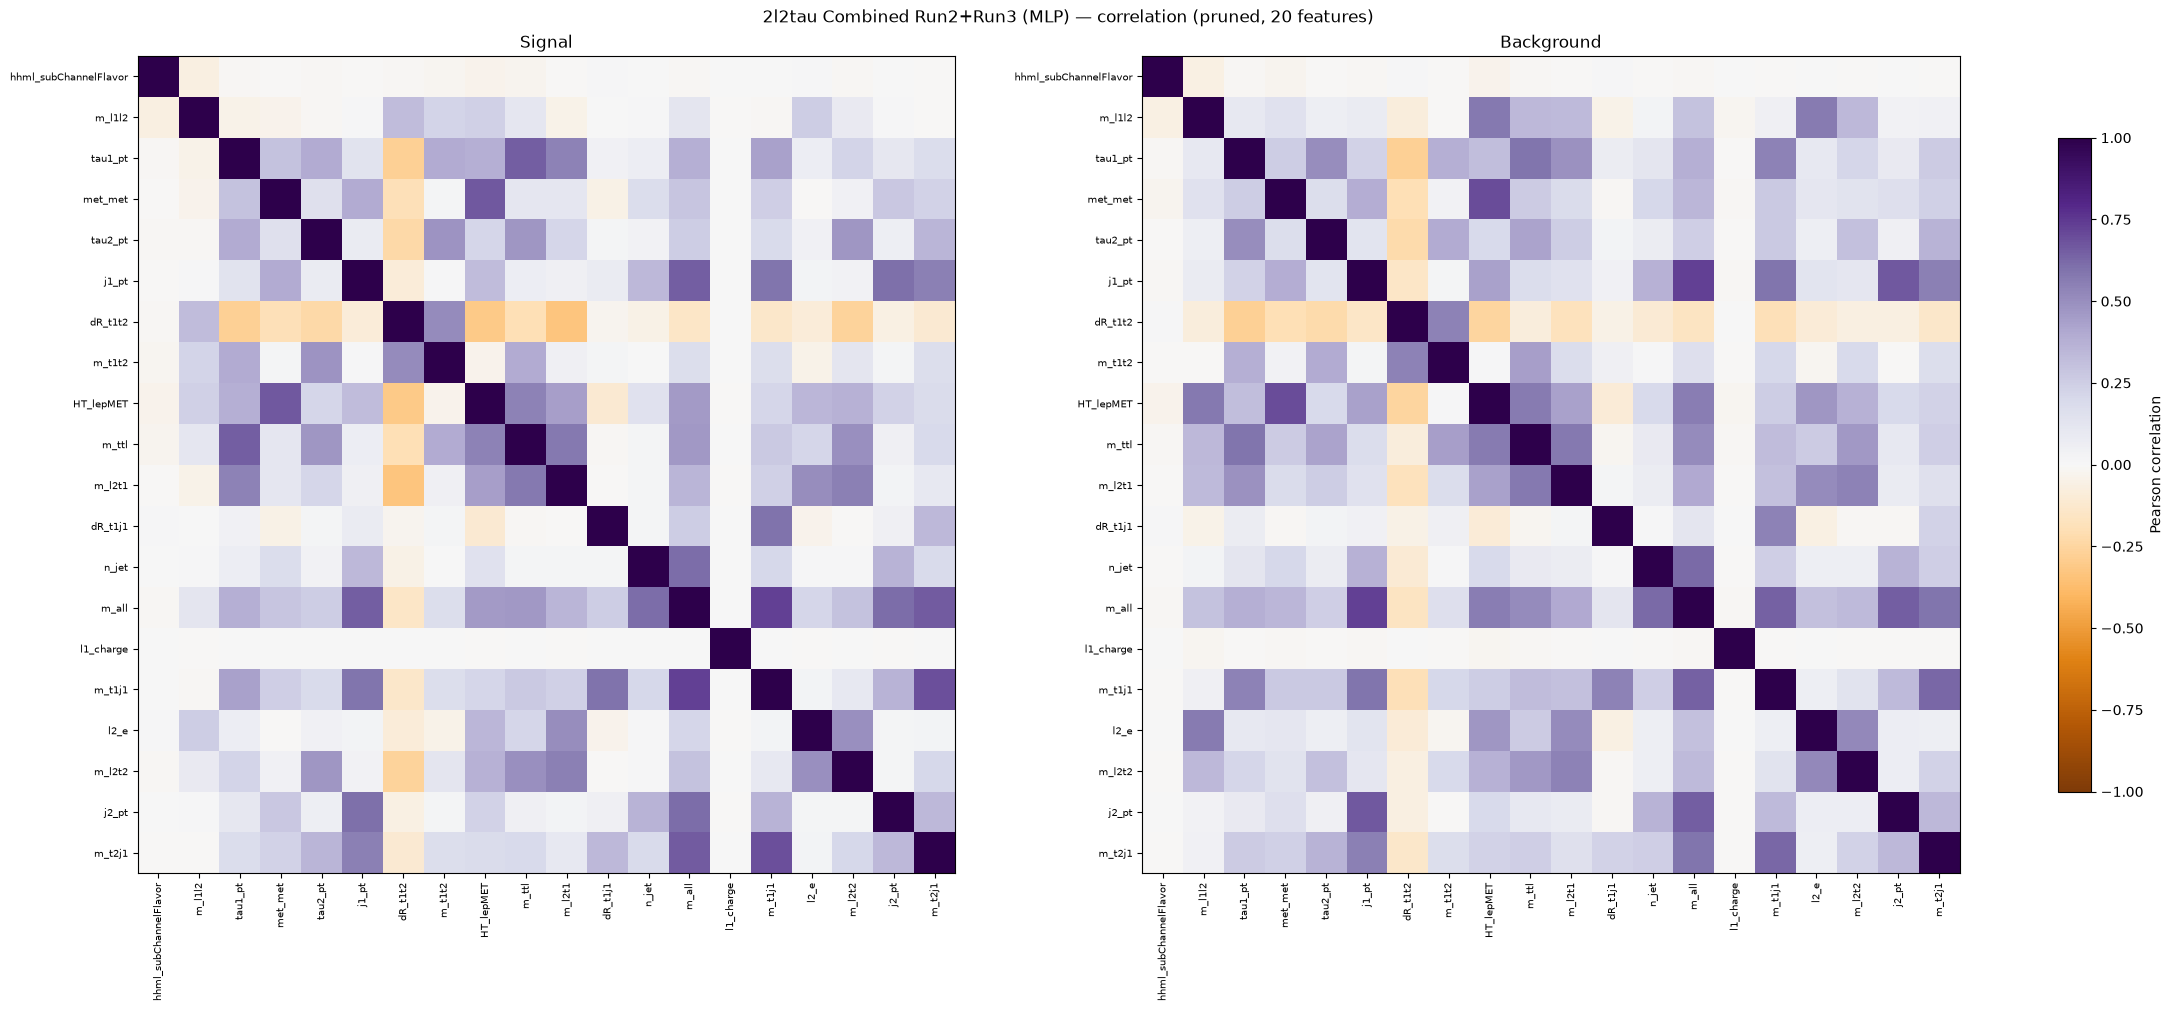

In [107]:
# ---- Retrain on the pruned feature set --------------------------------
def subset_feature_tensors_comb(feature_subset, all_features=features_comb):

    """
    Combined-track version of subset_feature_tensors: slices the
    already-scaled Combined train/val/test numpy arrays (X_train_scaled_comb/
    X_val_scaled_comb/X_test_scaled_comb) instead of the Run 2/Run 3 globals.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t


X_train_pruned_t_comb, X_val_pruned_t_comb, X_test_pruned_t_comb = subset_feature_tensors_comb(PRUNED_FEATURES_comb)

model_pruned_comb, history_pruned_comb, val_auc_pruned_comb, train_auc_pruned_comb, train_auc_eval_pruned_comb = train_model(
    hidden_sizes=best_hidden_sizes_comb, verbose=False,
    X_train_data=X_train_pruned_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_pruned_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

print(f"Full model      ({len(features_comb):2d} features): train_auc_eval = {best_train_auc_eval_comb:.4f} | val_auc = {best_val_auc_comb:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_comb):2d} features): train_auc_eval = {train_auc_eval_pruned_comb:.4f} | val_auc = {val_auc_pruned_comb:.4f}")

importance_pruned_comb = permutation_importance(model_pruned_comb, X_val_pruned_t_comb, y_val_t_comb, w_val_t_comb, PRUNED_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_pruned_comb, top_n=len(PRUNED_FEATURES_comb),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_comb)} features, Combined)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMB / "CombinedImportancePruned_DNN.png",
)

pruned_corrs_comb = grouped_correlations(data_comb, PRUNED_FEATURES_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_comb[1], pruned_corrs_comb[0]], ["Signal", "Background"], PRUNED_FEATURES_comb,
    suptitle=f"2l2tau Combined Run2+Run3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_comb)} features)",
    save_path=PLOTS_DIR_COMB / "CombinedCorrelationPruned_DNN.png",
)


## Top-15 Features Only — Combined

Kept 15 decorrelated features (most -> least important):
   1. hhml_subChannelFlavor
   2. m_l1l2
   3. tau1_pt
   4. met_met
   5. tau2_pt
   6. j1_pt
   7. dR_t1t2
   8. m_t1t2
   9. HT_lepMET
  10. m_ttl
  11. m_l2t1
  12. dR_t1j1
  13. n_jet
  14. m_all
  15. l1_charge

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.966)
  met_sumet       -> redundant with j1_pt           (|corr| = 0.821)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.884)
  HT              -> redundant with j1_pt           (|corr| = 0.830)
  HT_all          -> redundant with j1_pt           (|corr| = 0.838)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.919)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.789)


Baseline weighted AUC: 0.9765
Saved plot -> PPSSP_2026/2l2tau/combined/plots/CombinedImportanceTop15_DNN.png


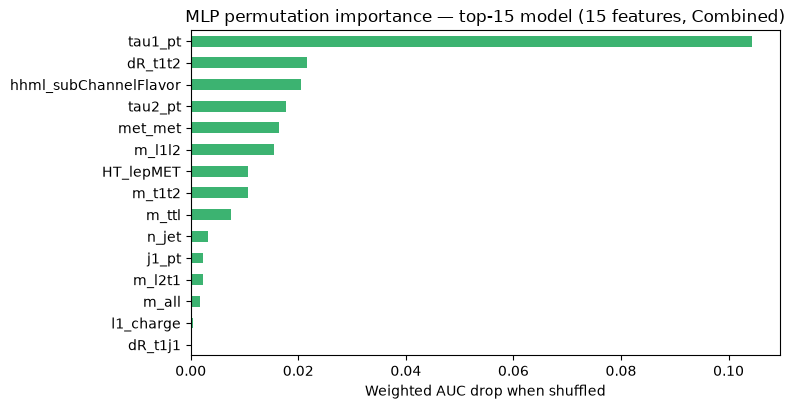


Weighted train(eval-mode)/validation AUC comparison (Combined):


,model,train_auc_eval,val_auc
2,Top-15 (15 features),0.978480,0.976456
1,Pruned (20 features),0.979631,0.976260
0,Full (81 features),0.987090,0.972762


In [108]:
TOP15_FEATURES_comb, dropped_top15_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, n_keep=15)

X_train_top15_t_comb, X_val_top15_t_comb, X_test_top15_t_comb = subset_feature_tensors_comb(TOP15_FEATURES_comb)

model_top15_comb, history_top15_comb, val_auc_top15_comb, train_auc_top15_comb, train_auc_eval_top15_comb = train_model(
    hidden_sizes=best_hidden_sizes_comb, verbose=False,
    X_train_data=X_train_top15_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_top15_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

importance_top15_comb = permutation_importance(model_top15_comb, X_val_top15_t_comb, y_val_t_comb, w_val_t_comb, TOP15_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_top15_comb, top_n=len(TOP15_FEATURES_comb),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_comb)} features, Combined)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_COMB / "CombinedImportanceTop15_DNN.png",
)

comparison_comb = pd.DataFrame([
    {"model": f"Full ({len(features_comb)} features)", "train_auc_eval": best_train_auc_eval_comb, "val_auc": best_val_auc_comb},
    {"model": f"Pruned ({len(PRUNED_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_pruned_comb, "val_auc": val_auc_pruned_comb},
    {"model": f"Top-15 ({len(TOP15_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_top15_comb, "val_auc": val_auc_top15_comb},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Combined):")
comparison_comb


## Physics Figure of Merit & Final Summary — Combined

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to the
Combined track's held-out TEST partition.


In [109]:
# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the Combined pruning walk above. The score
# CUT is selected here by scanning VAL only - it is applied FROZEN to test in
# the "Held-Out Test Evaluation" cell below, never re-scanned there.

models_registry_comb = {
    f"Full ({len(features_comb)} features)": (model_comb, X_val_t_comb, X_test_t_comb),
    f"Pruned ({len(PRUNED_FEATURES_comb)} features)": (model_pruned_comb, X_val_pruned_t_comb, X_test_pruned_t_comb),
    f"Top-15 ({len(TOP15_FEATURES_comb)} features)": (model_top15_comb, X_val_top15_t_comb, X_test_top15_t_comb),
}
best_name_comb = f"Top-15 ({len(TOP15_FEATURES_comb)} features)"

final_model_comb, X_val_final_t_comb, X_test_final_t_comb = models_registry_comb[best_name_comb]

final_model_comb.eval()
with torch.no_grad():
    val_scores_comb = torch.sigmoid(final_model_comb(X_val_final_t_comb)).cpu().numpy()

z_val_comb, thr_val_comb = significance_scan(y_val_comb, val_scores_comb, w_val_comb)  # signed w_phys - expected yields
final_val_auc_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "val_auc"].iloc[0]
final_train_auc_eval_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name_comb}")
print(f"Weighted val AUC = {final_val_auc_comb:.4f}")
print(f"Max Asimov Z (val) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9765
Max Asimov Z (val) = 0.042 at score cut = 0.9732


### Held-Out Test Evaluation (Combined)

`X_test_final_t_comb`/`y_test_comb`/`w_test_comb` have not participated in
anything above. This is the one place they are read: the final model is
scored once, and the VAL-selected score cut is applied frozen.


In [110]:
# ---- HELD-OUT TEST EVALUATION (Combined) — scored EXACTLY ONCE ------------
# X_test_final_t_comb/y_test_comb/w_test_comb have not been touched anywhere
# above - this is the only cell in the Combined section that reads them. The
# score cut `thr_val_comb` was chosen by scanning VAL only; it is applied
# here FROZEN, NOT re-scanned on test.

final_model_comb.eval()
with torch.no_grad():
    test_scores_comb = torch.sigmoid(final_model_comb(X_test_final_t_comb)).cpu().numpy()

auc_test_comb = roc_auc_score(y_test_comb, test_scores_comb, sample_weight=w_test_fit_comb)

S_test_comb = w_test_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 1)].sum()
B_test_comb = w_test_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 0)].sum()
z_test_comb = (np.sqrt(2 * ((S_test_comb + B_test_comb) * np.log(1 + S_test_comb / B_test_comb) - S_test_comb))
               if (S_test_comb > 0 and B_test_comb > 0) else np.nan)

print(f"Final model: {best_name_comb}")
print(f"Weighted AUC: val = {final_val_auc_comb:.4f}  |  test (held-out, scored once) = {auc_test_comb:.4f}")
print(f"At the VAL-selected score cut = {thr_val_comb:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_comb:.2f} | test B = {B_test_comb:.2f} | test Z = {z_test_comb:.3f}  (val Z was {z_val_comb:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9765  |  test (held-out, scored once) = 0.9765
At the VAL-selected score cut = 0.9732 (frozen, NOT re-scanned on test):
  test S = 0.05 | test B = 1.00 | test Z = 0.046  (val Z was 0.042)


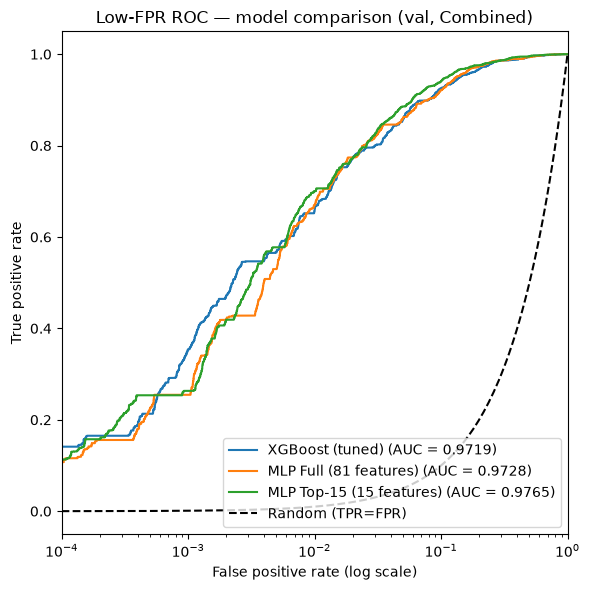

--- FPR = 1e-03 (~19 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.3542  (354x random lift)
  MLP Full (81 features)           TPR = 0.2547  (255x random lift)
  MLP Top-15 (15 features)         TPR = 0.2633  (263x random lift)
--- FPR = 1e-02 (~187 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.6573  (66x random lift)
  MLP Full (81 features)           TPR = 0.6701  (67x random lift)
  MLP Top-15 (15 features)         TPR = 0.7001  (70x random lift)


In [112]:
# ---- Load the tuned XGBoost model for the Combined Run2+Run3 track, for an
# apples-to-apples overlay. val_df_comb here is the Combined track's own
# holdout split (stratified on label AND run).

import xgboost as xgb

BASE_DIR_COMB = Path("PPSSP_2026/2l2tau/combined")

xgb_model_comb = xgb.XGBClassifier()
xgb_model_comb.load_model(BASE_DIR_COMB / "final_model_combined.json")
with open(BASE_DIR_COMB / "optuna_features_combined.json") as f:
    xgb_features_comb = json.load(f)

xgb_val_scores_comb = xgb_model_comb.predict_proba(val_df_comb[xgb_features_comb])[:, 1]

# ROC curve for the FINAL model (top-15 pruned, `val_scores_comb` from the
# significance-scan cell above), not the full model - matches the `best_name_comb` label.
fpr_val_comb, tpr_val_comb, _ = roc_curve(y_val_comb, val_scores_comb, sample_weight=w_val_fit_comb)

curves_comb = {
    "XGBoost (tuned)": roc_with_auc(y_val_comb, xgb_val_scores_comb, w_val_fit_comb),
    f"MLP Full ({len(features_comb)} features)": roc_with_auc(y_val_comb, val_probs_comb, w_val_fit_comb),
    f"MLP {best_name_comb}": (fpr_val_comb, tpr_val_comb, final_val_auc_comb),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_comb.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Combined)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_comb = int((y_val_comb == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_comb:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_comb.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert np.isfinite(X_train_scaled_comb).all() and np.isfinite(X_val_scaled_comb).all() and np.isfinite(X_test_scaled_comb).all(), \
    "NaN/inf reached the model input (Combined)"

# Determinism check, same convention as the Run 2/Run 3 sections.
set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED: {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test_comb, z_test_comb at the
# frozen, VAL-selected score cut).

summary_comb = pd.DataFrame([{
    "model": best_name_comb,
    "train_auc_eval": final_train_auc_eval_comb,
    "val_auc": final_val_auc_comb,
    "max_asimov_Z (val)": z_val_comb,
    "test_auc (held-out, scored once)": auc_test_comb,
    "test_Z_at_val_cut (held-out)": z_test_comb,
}])

print("\nFinal summary (MLP, 2l2tau Combined Run2+Run3):")
print(summary_comb.to_string(index=False))
summary_comb


Determinism check passed: two re-seeded runs give identical val_auc = 0.958491

Final summary (MLP, 2l2tau Combined Run2+Run3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.979571 0.978823            0.042434                          0.977347                      0.035742


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.979571,0.978823,0.042434,0.977347,0.035742


## Run 2 vs Run 3 — Domain-Shift Check

Self-contained check, independent of the DNN models above - it only reuses
the Combined track's tuned, decorrelated **feature list** persisted by
`2L2Tau_Master_Pipeline.ipynb` (`PPSSP_2026/2l2tau/combined/
optuna_features_combined.json`), since the question ("do Run 2 and Run 3
agree on the features that matter") is about the input data, not about
which downstream classifier (XGBoost/MLP/DNN) is used. Methodology,
outputs and file paths are identical to the XGBoost master pipeline's
Section 6/7 (same bootstrap-CI forest plot + AUC-tolerance pooling-decision
plot), so results are directly comparable rather than a near-duplicate
under a different name.

**Label convention:** Run 2 = 0, Run 3 = 1. **Weights:** the raw `weights`
branch is used AS-IS. **Reading the AUC:** ≈0.5 = indistinguishable runs;
well above 0.5 = a genuine shift, `AUC - 0.5` ≈ effect size.


In [113]:
# ---- Setup: load the Combined track's tuned feature list + Run2/Run3 signal events
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

PLOTS_DIR_DOMAIN = Path("run2_vs_run3_plots_2l2tau")
PLOTS_DIR_DOMAIN.mkdir(exist_ok=True)
RESULTS_CSV_DOMAIN = Path("run2_vs_run3_auc_summary_2l2tau.csv")

BASE_DIR_COMB_DOMAIN = Path("PPSSP_2026/2l2tau/combined")
with open(BASE_DIR_COMB_DOMAIN / "optuna_features_combined.json") as f:
    domain_features = json.load(f)
print(f"Loaded {len(domain_features)} features from {BASE_DIR_COMB_DOMAIN / 'optuna_features_combined.json'}")

SIGNAL_FILES = {"signal_ggF": "signal_ggF.root", "signal_VBF": "signal_VBF.root"}
WEIGHT_BRANCH = "weights"

frames = []
for run_label, run_name, base_dir in [(0, "Run 2", BASE_DIR_RUN2), (1, "Run 3", BASE_DIR_RUN3)]:
    for proc, fname in SIGNAL_FILES.items():
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(domain_features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
        print(f"{run_name:5s} {proc:12s}: {len(df):>8d} events after preselection")

domain_data = pd.concat(frames, ignore_index=True)
for feat in domain_features:
    m = domain_data[feat] < -100
    if m.any():
        domain_data[feat] = domain_data[feat].mask(m)

X_domain = domain_data[domain_features]
y_domain = domain_data["run_label"].to_numpy()
w_domain_raw = domain_data[WEIGHT_BRANCH].to_numpy()
w_domain_abs = np.abs(w_domain_raw)

w_domain_fit = w_domain_abs.copy()
sum_r2, sum_r3 = w_domain_fit[y_domain == 0].sum(), w_domain_fit[y_domain == 1].sum()
w_domain_fit[y_domain == 1] *= sum_r2 / sum_r3
w_domain_fit *= len(w_domain_fit) / w_domain_fit.sum()


def bootstrap_weighted_auc_ci(y, pred, w_abs, n_boot=1000, ci=0.95, random_state=RANDOM_STATE):
    """Percentile bootstrap CI for a weighted AUC over out-of-fold
    predictions - see 2L2Tau_Master_Pipeline.ipynb Section 6 for the
    full derivation/verification of this O(n) resample trick."""
    rng = np.random.default_rng(random_state)
    y, pred, w_abs = np.asarray(y), np.asarray(pred), np.asarray(w_abs)
    n = len(y)
    trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    order = np.argsort(pred, kind="stable")
    y_s, w_s = y[order], w_abs[order]
    y_desc = y_s[::-1]
    pred_desc = pred[order][::-1]
    is_pos_desc = y_desc == 1
    distinct_desc = np.empty(n, dtype=bool)
    distinct_desc[:-1] = pred_desc[:-1] != pred_desc[1:]
    distinct_desc[-1] = True

    boot_aucs = []
    attempts = 0
    while len(boot_aucs) < n_boot and attempts < n_boot * 20:
        attempts += 1
        idx = rng.integers(0, n, n)
        counts = np.bincount(idx, minlength=n)
        eff_w_desc = (w_s * counts[order])[::-1]
        tp_weight = np.where(is_pos_desc, eff_w_desc, 0.0)
        fp_weight = np.where(~is_pos_desc, eff_w_desc, 0.0)
        cum_tp, cum_fp = np.cumsum(tp_weight), np.cumsum(fp_weight)
        total_tp, total_fp = cum_tp[-1], cum_fp[-1]
        if total_tp == 0 or total_fp == 0:
            continue
        tpr = np.concatenate(([0.0], cum_tp[distinct_desc] / total_tp))
        fpr = np.concatenate(([0.0], cum_fp[distinct_desc] / total_fp))
        boot_aucs.append(trapz(tpr, fpr))

    boot_aucs = np.array(boot_aucs)
    lo, hi = np.percentile(boot_aucs, [100 * (1 - ci) / 2, 100 * (1 + ci) / 2])
    return lo, hi, boot_aucs


# ---- Stratified K-Fold with out-of-fold predictions (no early stopping - see master pipeline notes) --
N_FOLDS_DOMAIN = 5
cv_domain = StratifiedKFold(n_splits=N_FOLDS_DOMAIN, shuffle=True, random_state=RANDOM_STATE)
domain_fold_aucs = []
oof_pred_signal = np.full(len(y_domain), np.nan)

for fold, (idx_tr, idx_te) in enumerate(cv_domain.split(X_domain, y_domain), start=1):
    fold_model = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=1.0, tree_method="hist",
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    fold_model.fit(X_domain.iloc[idx_tr], y_domain[idx_tr], sample_weight=w_domain_fit[idx_tr])
    pred = fold_model.predict_proba(X_domain.iloc[idx_te])[:, 1]
    oof_pred_signal[idx_te] = pred
    fold_auc = roc_auc_score(y_domain[idx_te], pred, sample_weight=w_domain_abs[idx_te])
    domain_fold_aucs.append(fold_auc)
    print(f"Fold {fold}/{N_FOLDS_DOMAIN}: weighted AUC = {fold_auc:.4f}")

domain_fold_aucs = np.array(domain_fold_aucs)
print(f"\nMean weighted AUC across {N_FOLDS_DOMAIN} folds: {domain_fold_aucs.mean():.4f} \u00b1 {domain_fold_aucs.std():.4f}")

ci_lo_signal, ci_hi_signal, _ = bootstrap_weighted_auc_ci(y_domain, oof_pred_signal, w_domain_abs, n_boot=2000)
print(f"Bootstrap 95% CI on OOF weighted AUC: [{ci_lo_signal:.4f}, {ci_hi_signal:.4f}]")


Loaded 20 features from PPSSP_2026/2l2tau/combined/optuna_features_combined.json
Run 2 signal_ggF  :    31959 events after preselection
Run 2 signal_VBF  :     5598 events after preselection


Run 3 signal_ggF  :    96909 events after preselection
Run 3 signal_VBF  :     3439 events after preselection
Fold 1/5: weighted AUC = 0.5216
Fold 2/5: weighted AUC = 0.5125
Fold 3/5: weighted AUC = 0.5224
Fold 4/5: weighted AUC = 0.5203
Fold 5/5: weighted AUC = 0.5212

Mean weighted AUC across 5 folds: 0.5196 ± 0.0036
Bootstrap 95% CI on OOF weighted AUC: [0.5156, 0.5233]


In [114]:
# ---- All-processes scan: repeat the two-sample test for every process ------
def run_two_sample_test(process_name, fname, features=domain_features, n_folds=3, n_estimators=200):
    frames = []
    for run_label, base_dir in [(0, BASE_DIR_RUN2), (1, BASE_DIR_RUN3)]:
        tree = uproot.open({str(base_dir / fname): TREE_NAME})
        df = tree.arrays(features + [WEIGHT_BRANCH], cut=PRESELECTION, library="pd")
        df["run_label"] = run_label
        frames.append(df)
    data = pd.concat(frames, ignore_index=True)
    for feat in features:
        m = data[feat] < -100
        if m.any():
            data[feat] = data[feat].mask(m)

    n_r2 = int((data.run_label == 0).sum())
    n_r3 = int((data.run_label == 1).sum())
    X_proc, y_proc = data[features], data["run_label"].to_numpy()
    w_abs_proc = np.abs(data[WEIGHT_BRANCH].to_numpy())

    w_fit_proc = w_abs_proc.copy()
    sum_r2p, sum_r3p = w_fit_proc[y_proc == 0].sum(), w_fit_proc[y_proc == 1].sum()
    if sum_r2p > 0 and sum_r3p > 0:
        w_fit_proc[y_proc == 1] *= sum_r2p / sum_r3p
        w_fit_proc *= len(w_fit_proc) / w_fit_proc.sum()

    n_splits = min(n_folds, n_r2, n_r3)
    fold_aucs = []
    oof_pred_proc = np.full(len(y_proc), np.nan)
    if n_splits >= 2:
        cv_proc = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        for idx_tr, idx_te in cv_proc.split(X_proc, y_proc):
            fm = xgb.XGBClassifier(n_estimators=n_estimators, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                                    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
            fm.fit(X_proc.iloc[idx_tr], y_proc[idx_tr], sample_weight=w_fit_proc[idx_tr])
            pred = fm.predict_proba(X_proc.iloc[idx_te])[:, 1]
            oof_pred_proc[idx_te] = pred
            fold_aucs.append(roc_auc_score(y_proc[idx_te], pred, sample_weight=w_abs_proc[idx_te]))

    fold_aucs = np.array(fold_aucs)
    mean_auc = float(fold_aucs.mean()) if len(fold_aucs) else np.nan
    std_auc = float(fold_aucs.std()) if len(fold_aucs) else np.nan
    if n_splits >= 2:
        ci_lo, ci_hi, _ = bootstrap_weighted_auc_ci(y_proc, oof_pred_proc, w_abs_proc, n_boot=1000)
    else:
        ci_lo = ci_hi = np.nan

    print(f"{process_name:12s}: Run2 = {n_r2:>7d} | Run3 = {n_r3:>7d} | "
          f"weighted AUC = {mean_auc:.4f} \u00b1 {std_auc:.4f} ({n_splits} folds)")

    return {"process": process_name, "n_run2": n_r2, "n_run3": n_r3,
            "n_folds": n_splits, "mean_auc": mean_auc, "std_auc": std_auc,
            "ci_lo": ci_lo, "ci_hi": ci_hi}


results = [run_two_sample_test(proc, fname) for proc, (fname, _label) in FILES.items()]
results_df = pd.DataFrame(results).sort_values("mean_auc", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_CSV_DOMAIN, index=False)
print(f"\nSaved AUC summary ({len(results_df)} processes) -> {RESULTS_CSV_DOMAIN}")
results_df


signal_ggF  : Run2 =   31959 | Run3 =   96909 | weighted AUC = 0.5167 ± 0.0018 (3 folds)
signal_VBF  : Run2 =    5598 | Run3 =    3439 | weighted AUC = 0.4900 ± 0.0029 (3 folds)
Diboson     : Run2 =   36877 | Run3 =   82336 | weighted AUC = 0.5445 ± 0.0030 (3 folds)
Zjets       : Run2 =    7746 | Run3 =   12919 | weighted AUC = 0.5464 ± 0.0198 (3 folds)
Wjets       : Run2 =      67 | Run3 =      51 | weighted AUC = 0.3727 ± 0.1004 (3 folds)
ttbar       : Run2 =     331 | Run3 =    3276 | weighted AUC = 0.5067 ± 0.0116 (3 folds)
tops        : Run2 =    3832 | Run3 =   11065 | weighted AUC = 0.5437 ± 0.0323 (3 folds)
SingleH     : Run2 =    2946 | Run3 =    3240 | weighted AUC = 0.6550 ± 0.0101 (3 folds)
Vgamma      : Run2 =    2019 | Run3 =    2366 | weighted AUC = 0.5488 ± 0.0176 (3 folds)
VVV         : Run2 =    3593 | Run3 =   13941 | weighted AUC = 0.6141 ± 0.0232 (3 folds)

Saved AUC summary (10 processes) -> run2_vs_run3_auc_summary_2l2tau.csv


,process,n_run2,n_run3,n_folds,mean_auc,std_auc,ci_lo,ci_hi
0,SingleH,2946,3240,3,0.655005,0.010091,0.605206,0.704338
1,VVV,3593,13941,3,0.614096,0.023241,0.589423,0.636049
2,Vgamma,2019,2366,3,0.548779,0.017642,0.502530,0.586060
3,Zjets,7746,12919,3,0.546400,0.019752,0.522221,0.571688
4,Diboson,36877,82336,3,0.544471,0.002976,0.536309,0.551601
5,tops,3832,11065,3,0.543736,0.032276,0.471929,0.618839
6,signal_ggF,31959,96909,3,0.516683,0.001791,0.512940,0.520465
7,ttbar,331,3276,3,0.506666,0.011649,0.473578,0.542380
8,signal_VBF,5598,3439,3,0.490016,0.002858,0.476824,0.503148
9,Wjets,67,51,3,0.372678,0.100367,0.170429,0.585141


Saved plot -> PPSSP_2026/2l2tau/summary_plots/AUCSummaryDomainShiftForestPlot_DNN.png


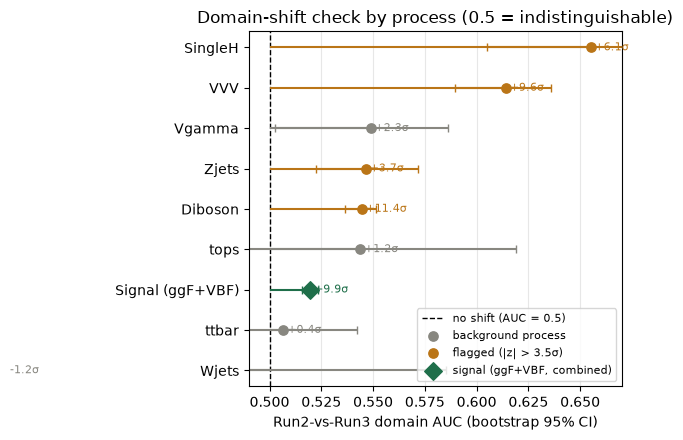


Flagged at |z| > 3.5σ:
         process  mean_auc         z
Signal (ggF+VBF)  0.519589  9.946747
         Diboson  0.544471 11.399895
           Zjets  0.546400  3.677014
             VVV  0.614096  9.592470
         SingleH  0.655005  6.129386


In [ ]:
# ---- Forest plot (0.5 = good) + pooling-decision plot -----------------------
PLOTS_DIR_SUMMARY = Path("PPSSP_2026/2l2tau/summary_plots")
PLOTS_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

is_signal_process = results_df["process"].map(lambda p: FILES.get(p, (None, 0))[1] == 1)
forest_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()
forest_df["se"] = (forest_df["ci_hi"] - forest_df["ci_lo"]) / (2 * 1.96)
forest_df["z"] = (forest_df["mean_auc"] - 0.5) / forest_df["se"]

se_signal = (ci_hi_signal - ci_lo_signal) / (2 * 1.96)
signal_row = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": domain_fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
    "z": (domain_fold_aucs.mean() - 0.5) / se_signal,
}])
plot_df_forest = pd.concat(
    [forest_df[["process", "mean_auc", "ci_lo", "ci_hi", "z"]], signal_row], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

Z_THRESH = 3.5
is_sig_f = (plot_df_forest["process"] == "Signal (ggF+VBF)").to_numpy()
flag_f = (plot_df_forest["z"].abs() > Z_THRESH).to_numpy()
group_f = np.where(is_sig_f, "signal", np.where(flag_f, "flagged", "normal"))
GROUP_STYLE = {
    "normal":  dict(color="#888780", marker="o", size=45, label="background process"),
    "flagged": dict(color="#BA7517", marker="o", size=45, label=f"flagged (|z| > {Z_THRESH}\u03c3)"),
    "signal":  dict(color="#1f6f4a", marker="D", size=80, label="signal (ggF+VBF, combined)"),
}

y_pos = np.arange(len(plot_df_forest))
mean_auc_f = plot_df_forest["mean_auc"].to_numpy()
xerr_lo = (plot_df_forest["mean_auc"] - plot_df_forest["ci_lo"]).clip(lower=0).to_numpy()
xerr_hi = (plot_df_forest["ci_hi"] - plot_df_forest["mean_auc"]).clip(lower=0).to_numpy()

fig, ax = plt.subplots(figsize=(8, max(4.5, 0.42 * len(plot_df_forest))))
ax.axvline(0.5, color="k", lw=1, ls="--", label="no shift (AUC = 0.5)")
for g, style in GROUP_STYLE.items():
    mask = group_f == g
    if not mask.any():
        continue
    c = style["color"]
    ax.hlines(y_pos[mask], 0.5, mean_auc_f[mask], color=c, lw=1.5, zorder=2)
    ax.errorbar(mean_auc_f[mask], y_pos[mask], xerr=[xerr_lo[mask], xerr_hi[mask]],
                fmt="none", ecolor=c, capsize=3, zorder=2)
    ax.scatter(mean_auc_f[mask], y_pos[mask], color=c, s=style["size"], marker=style["marker"],
               zorder=3, label=style["label"])
for yi, z in zip(y_pos, plot_df_forest["z"]):
    ax.text(mean_auc_f[yi] + 0.002, yi, f"{z:+.1f}\u03c3", va="center", fontsize=8,
            color=GROUP_STYLE[group_f[yi]]["color"])
ax.set(yticks=y_pos, yticklabels=plot_df_forest["process"],
       xlim=(0.49, max(0.56, mean_auc_f.max() + 0.015)),
       xlabel="Run2-vs-Run3 domain AUC (bootstrap 95% CI)",
       title="Domain-shift check by process (0.5 = indistinguishable)")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
forest_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryDomainShiftForestPlot_DNN.png"
fig.savefig(forest_plot_path, dpi=150)
print(f"Saved plot -> {forest_plot_path}")
plt.show()

flagged = plot_df_forest.loc[plot_df_forest["z"].abs() > Z_THRESH, ["process", "mean_auc", "z"]]
print(f"\nFlagged at |z| > {Z_THRESH}\u03c3:")
print(flagged.to_string(index=False) if len(flagged) else "  none")


Saved plot -> PPSSP_2026/2l2tau/summary_plots/AUCSummaryDomainShiftPoolingCheck_DNN.png


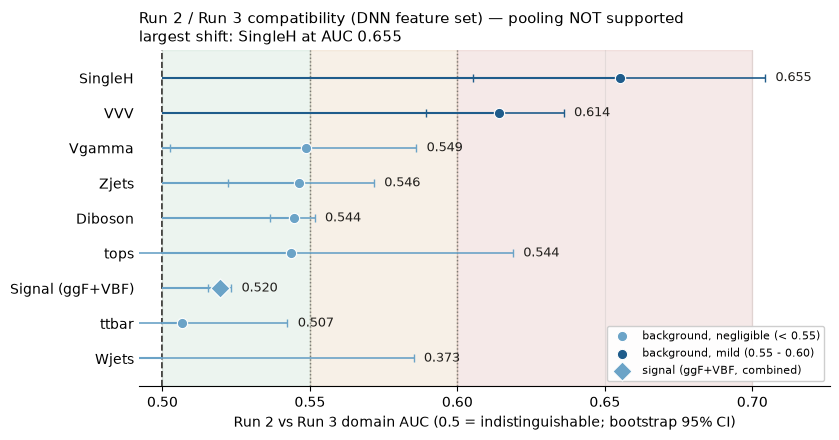


Max domain AUC = 0.655  (tolerance 0.6)
Verdict: pooling NOT supported


In [115]:
# ---- Domain-shift plot: can Run 2 and Run 3 be pooled? ----------------------
AUC_NEGLIGIBLE = 0.55
AUC_TOLERABLE = 0.60

bkg_df = results_df.loc[~is_signal_process].dropna(subset=["ci_lo", "ci_hi"]).copy()
signal_row_pool = pd.DataFrame([{
    "process": "Signal (ggF+VBF)", "mean_auc": domain_fold_aucs.mean(),
    "ci_lo": ci_lo_signal, "ci_hi": ci_hi_signal,
}])
plot_df_pool = pd.concat(
    [bkg_df[["process", "mean_auc", "ci_lo", "ci_hi"]], signal_row_pool], ignore_index=True
).sort_values("mean_auc").reset_index(drop=True)

y_pos = np.arange(len(plot_df_pool))
mean_auc_p = plot_df_pool["mean_auc"].to_numpy()
ci_lo_p, ci_hi_p = plot_df_pool["ci_lo"].to_numpy(), plot_df_pool["ci_hi"].to_numpy()
is_signal_p = (plot_df_pool["process"] == "Signal (ggF+VBF)").to_numpy()
is_watch_p = mean_auc_p >= AUC_NEGLIGIBLE
INK, MUTED = "#22201d", "#6b6862"
C_LOW, C_WATCH = "#6BA3C7", "#1F5C8B"

fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.46 * len(plot_df_pool))))
ax.axvspan(0.50, AUC_NEGLIGIBLE, color="#4C9A6A", alpha=0.10, zorder=0)
ax.axvspan(AUC_NEGLIGIBLE, AUC_TOLERABLE, color="#BA7517", alpha=0.10, zorder=0)
ax.axvspan(AUC_TOLERABLE, 0.70, color="#A62B1F", alpha=0.10, zorder=0)
for x in (AUC_NEGLIGIBLE, AUC_TOLERABLE):
    ax.axvline(x, color=MUTED, lw=1, ls=":", zorder=1)
ax.axvline(0.5, color=INK, lw=1.2, ls="--", zorder=1)

for label, colour, mask, marker, size in [
    ("background, negligible (< 0.55)", C_LOW, ~is_watch_p & ~is_signal_p, "o", 55),
    ("background, mild (0.55 - 0.60)", C_WATCH, is_watch_p & ~is_signal_p, "o", 55),
    ("signal (ggF+VBF, combined)", C_WATCH if is_watch_p[is_signal_p][0] else C_LOW, is_signal_p, "D", 95),
]:
    if not mask.any():
        continue
    ax.hlines(y_pos[mask], 0.5, mean_auc_p[mask], color=colour, lw=1.5, zorder=2)
    ax.errorbar(mean_auc_p[mask], y_pos[mask], xerr=[mean_auc_p[mask] - ci_lo_p[mask], ci_hi_p[mask] - mean_auc_p[mask]],
                fmt="none", ecolor=colour, capsize=3, lw=1.2, zorder=2)
    ax.scatter(mean_auc_p[mask], y_pos[mask], color=colour, s=size, marker=marker, zorder=3,
               label=label, edgecolor="white", linewidth=0.8)

for yi in y_pos:
    ax.text(ci_hi_p[yi] + 0.0035, yi, f"{mean_auc_p[yi]:.3f}", va="center", fontsize=9, color=INK)

x_max = max(AUC_TOLERABLE + 0.012, ci_hi_p.max() + 0.022)
ax.set(yticks=y_pos, yticklabels=plot_df_pool["process"], xlim=(0.492, x_max),
       ylim=(-0.8, len(plot_df_pool) - 0.2),
       xlabel="Run 2 vs Run 3 domain AUC (0.5 = indistinguishable; bootstrap 95% CI)")
worst = plot_df_pool.iloc[-1]
verdict = "supports pooling" if mean_auc_p.max() < AUC_TOLERABLE else "pooling NOT supported"
ax.set_title(f"Run 2 / Run 3 compatibility (DNN feature set) — {verdict}\n"
             f"largest shift: {worst['process']} at AUC {worst['mean_auc']:.3f}", fontsize=11, loc="left")
ax.grid(axis="x", alpha=0.25, zorder=0)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(loc="lower right", fontsize=8, frameon=True, framealpha=0.95)
plt.tight_layout()

pool_plot_path = PLOTS_DIR_SUMMARY / "AUCSummaryDomainShiftPoolingCheck_DNN.png"
fig.savefig(pool_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot -> {pool_plot_path}")
plt.show()

print(f"\nMax domain AUC = {mean_auc_p.max():.3f}  (tolerance {AUC_TOLERABLE:g})")
print(f"Verdict: {verdict}")


In [ ]:
# ---- Export standardized AUC summary for cross-notebook comparison ---------
# Written for ModelComparison.ipynb to load - one row per track, so it can be
# combined with the XGBoost/sibling notebook's own exports without needing
# to re-run anything.

model_summary_rows = [
    {"channel": "2l2tau", "model": "dnn", "track": "Run 2",
      "val_auc": final_val_auc, "test_auc": auc_test},
    {"channel": "2l2tau", "model": "dnn", "track": "Run 3",
      "val_auc": final_val_auc_run3, "test_auc": auc_test_run3},
    {"channel": "2l2tau", "model": "dnn", "track": "Combined",
      "val_auc": final_val_auc_comb, "test_auc": auc_test_comb},
]
model_summary_df = pd.DataFrame(model_summary_rows)
PLOTS_DIR_SUMMARY_EXPORT = Path("PPSSP_2026/2l2tau/summary_plots")
PLOTS_DIR_SUMMARY_EXPORT.mkdir(parents=True, exist_ok=True)
model_summary_path = PLOTS_DIR_SUMMARY_EXPORT / "model_summary_dnn.csv"
model_summary_df.to_csv(model_summary_path, index=False)
print(f"Saved model comparison summary -> {model_summary_path}")
model_summary_df


Saved model comparison summary -> PPSSP_2026/2l2tau/summary_plots/model_summary_dnn.csv


,channel,model,track,val_auc,test_auc
0,2l2tau,dnn,Run 2,0.974798,0.972081
1,2l2tau,dnn,Run 3,0.981916,0.978142
2,2l2tau,dnn,Combined,0.978823,0.977347
